# IMF Paper Replication: Debt, Deficits, and Term Premia

Replicating: "The Effect of Debt and Deficits on Term Premia" (Furceri, Goncalves, Li 2025)

**Methodology:**
- Event-based daily matching (CBO release date → first trading day after)
- OLS with Newey-West HAC standard errors (3 lags)
- Time trends: linear + quadratic

**Data Pipeline (run-time refresh):**
- Fiscal data: CBO files are loaded from `data/data_quarterly/*_all_releases.csv` each run
- Optional full fiscal rebuild: set `force_refresh_cbo = True` in the CBO cell
- Forward rates: downloaded from Federal Reserve GSW table (`feds200628.csv`) each run
- Treasury yield: `DGS10` downloaded from FRED each run
- Term premia: loaded from local `ACMTermPremium.xlsx`

**Model Blocks:**
1. Event-based daily regressions (fiscal variable + time trends)
2. Quarterly M1–M4 models (progressively adding controls)

**Important:** Observation counts and sample windows are run-dependent and printed by the code cells; avoid treating older hardcoded counts as fixed.

In [13]:
import subprocess
import sys

# Install required packages
packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'statsmodels',
    'openpyxl',
    'scipy',
    'requests'
 ]
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.api import OLS, add_constant

print("All required packages installed and imported!")

All required packages installed and imported!


## CBO Data Inventory Summary

This notebook uses the CBO all-release fiscal files in `data/data_quarterly/`:
- `debt_5y_with_gdp_all_releases.csv`
- `deficit_5y_with_gdp_all_releases.csv`
- `fiscal_balance_5y_with_gdp_all_releases.csv`
- `primary_balance_5y_with_gdp_all_releases.csv`

The event-study sample is built from the union of available baseline dates across these files.
Exact counts and date ranges are printed at run time in the CBO loading cell.

**Refresh behavior:**
- Fast default: reuses existing fiscal files (no long rebuild)
- Full rebuild: set `force_refresh_cbo = True` in the CBO cell

This keeps the notebook reproducible while avoiding unnecessary long-running refreshes.

In [14]:
print("\n1a. CBO fiscal data refresh (fast mode)...")

import subprocess
from pathlib import Path

cbo_src_dir = Path('data/cbo_data/src')
required_outputs = [
    Path('data/data_quarterly/debt_5y_with_gdp_all_releases.csv'),
    Path('data/data_quarterly/deficit_5y_with_gdp_all_releases.csv'),
    Path('data/data_quarterly/fiscal_balance_5y_with_gdp_all_releases.csv'),
    Path('data/data_quarterly/primary_balance_5y_with_gdp_all_releases.csv'),
]

# Fast default: avoid long rebuild unless missing files or manual override.
force_refresh_cbo = False
missing_outputs = [p for p in required_outputs if not p.exists()]
needs_refresh = force_refresh_cbo or bool(missing_outputs)

if needs_refresh:
    print('   Regenerating CBO fiscal datasets...')
    if missing_outputs:
        print('   Missing files:')
        for p in missing_outputs:
            print(f'     - {p}')

    for cmd in (['python', 'main.py', 'debt'], ['python', 'main.py', 'deficit']):
        label = ' '.join(cmd)
        try:
            print(f'   Running: {label}')
            result = subprocess.run(
                cmd,
                cwd=str(cbo_src_dir),
                capture_output=True,
                text=True,
                timeout=90
            )
            if result.returncode == 0:
                print(f'   ✓ Completed: {label}')
            else:
                print(f'   ⚠ Non-zero exit ({result.returncode}) for: {label}')
                if result.stderr:
                    print(result.stderr[:300])
        except subprocess.TimeoutExpired:
            print(f'   ⚠ Timed out: {label} (90s)')
        except Exception as exc:
            print(f'   ⚠ Failed: {label} | {exc}')
else:
    print('   ✓ Using existing CBO fiscal files (no rebuild).')
    print('   Set force_refresh_cbo = True to force regeneration.')

print("\n1b. Loading CBO 5-year forecasts (all-release datasets)...")

debt_5y = pd.read_csv('data/data_quarterly/debt_5y_with_gdp_all_releases.csv')
deficit_5y = pd.read_csv('data/data_quarterly/deficit_5y_with_gdp_all_releases.csv')
fiscal_balance_5y = pd.read_csv('data/data_quarterly/fiscal_balance_5y_with_gdp_all_releases.csv')
primary_balance_5y = pd.read_csv('data/data_quarterly/primary_balance_5y_with_gdp_all_releases.csv')

for df in [debt_5y, deficit_5y, fiscal_balance_5y, primary_balance_5y]:
    df['baseline_date'] = pd.to_datetime(df['baseline_date'])

cbo_dates = sorted(
    set(debt_5y['baseline_date'].unique())
    | set(deficit_5y['baseline_date'].unique())
    | set(fiscal_balance_5y['baseline_date'].unique())
    | set(primary_balance_5y['baseline_date'].unique())
)

print(f"   Debt forecasts: {len(debt_5y)} observations")
print(f"   Deficit forecasts: {len(deficit_5y)} observations")
print(f"   Fiscal balance forecasts: {len(fiscal_balance_5y)} observations")
print(f"   Primary balance forecasts: {len(primary_balance_5y)} observations")
print(f"   Unique CBO release dates (union): {len(cbo_dates)}")
print(f"   Date range: {cbo_dates[0].date()} to {cbo_dates[-1].date()}")


1a. CBO fiscal data refresh (fast mode)...
   ✓ Using existing CBO fiscal files (no rebuild).
   Set force_refresh_cbo = True to force regeneration.

1b. Loading CBO 5-year forecasts (all-release datasets)...
   Debt forecasts: 44 observations
   Deficit forecasts: 99 observations
   Fiscal balance forecasts: 99 observations
   Primary balance forecasts: 87 observations
   Unique CBO release dates (union): 99
   Date range: 1984-02-01 to 2025-01-01


## Data Preparation

In [15]:
print("\n1b. Downloading market series (GSW forwards + DGS10)...")

from pathlib import Path
import io
import requests

output_dir = Path('data/data_quarterly')
output_dir.mkdir(parents=True, exist_ok=True)

headers = {
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'text/csv,application/octet-stream,*/*',
    'Referer': 'https://www.federalreserve.gov/'
}

def _fetch_csv(url, timeout=45):
    resp = requests.get(url, headers=headers, timeout=timeout)
    resp.raise_for_status()
    return pd.read_csv(io.StringIO(resp.text))

# 1) DGS10 from FRED (direct CSV endpoint; avoids pandas_datareader dependency)
dgs10_cache = output_dir / 'DGS10.csv'
try:
    dgs10_url = 'https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10'
    dgs10_fred = _fetch_csv(dgs10_url)
    dgs10_fred.columns = ['observation_date', 'DGS10']
    dgs10_fred['observation_date'] = pd.to_datetime(dgs10_fred['observation_date'], errors='coerce')
    dgs10_fred['DGS10'] = pd.to_numeric(dgs10_fred['DGS10'], errors='coerce')
    dgs10_fred = dgs10_fred.dropna(subset=['observation_date', 'DGS10'])
    dgs10_fred.to_csv(dgs10_cache, index=False)
    print(f"   ✓ DGS10: {len(dgs10_fred)} observations saved")
except Exception as e:
    if dgs10_cache.exists():
        cached_dgs10 = pd.read_csv(dgs10_cache)
        print(f"   ⚠ DGS10 download failed ({e}); using cached file with {len(cached_dgs10)} rows")
    else:
        print(f"   ✗ DGS10: {e}")

# 2) GSW forward curve from Federal Reserve (source requested)
gsw_cache = output_dir / 'gsw_forward_rates.csv'
try:
    gsw_url = 'https://www.federalreserve.gov/data/yield-curve-tables/feds200628.csv'
    resp = requests.get(gsw_url, headers=headers, timeout=45)
    resp.raise_for_status()

    # GSW file has metadata rows at the top; parse tabular block starting at row 10
    gsw = pd.read_csv(io.StringIO(resp.text), skiprows=9)
    if 'Date' in gsw.columns:
        gsw = gsw.rename(columns={'Date': 'observation_date'})
    else:
        gsw = gsw.rename(columns={gsw.columns[0]: 'observation_date'})

    gsw['observation_date'] = pd.to_datetime(gsw['observation_date'], errors='coerce')

    # Fed currently serves forwards as SVENF##; map to FORWARD# aliases
    for n in range(1, 31):
        sven_col = f'SVENF{n:02d}'
        fwd_col = f'FORWARD{n}'
        if sven_col in gsw.columns and fwd_col not in gsw.columns:
            gsw[fwd_col] = pd.to_numeric(gsw[sven_col], errors='coerce')

    required_cols = [
        'FORWARD5', 'FORWARD6', 'FORWARD7', 'FORWARD8', 'FORWARD9',
        'FORWARD10', 'FORWARD11', 'FORWARD12', 'FORWARD13', 'FORWARD14'
    ]
    missing_cols = [c for c in required_cols if c not in gsw.columns]
    if missing_cols:
        raise ValueError(f'Missing expected GSW forward columns after mapping: {missing_cols}')

    for col in required_cols:
        gsw[col] = pd.to_numeric(gsw[col], errors='coerce')

    # 5-10Y forward: average of FORWARD5...FORWARD9
    gsw['fwd_5_10y'] = gsw[['FORWARD5', 'FORWARD6', 'FORWARD7', 'FORWARD8', 'FORWARD9']].mean(axis=1)

    # 10-15Y forward: average of FORWARD10...FORWARD14
    gsw['fwd_10_15y'] = gsw[['FORWARD10', 'FORWARD11', 'FORWARD12', 'FORWARD13', 'FORWARD14']].mean(axis=1)

    gsw = gsw[['observation_date'] + required_cols + ['fwd_5_10y', 'fwd_10_15y']]
    gsw = gsw.dropna(subset=['observation_date']).dropna(how='all')
    gsw.to_csv(gsw_cache, index=False)

    print(f"   ✓ GSW forwards: {len(gsw)} observations saved")
    print("   ✓ Computed: fwd_5_10y = mean(FORWARD5..FORWARD9)")
    print("   ✓ Computed: fwd_10_15y = mean(FORWARD10..FORWARD14)")
except Exception as e:
    if gsw_cache.exists():
        cached_gsw = pd.read_csv(gsw_cache)
        print(f"   ⚠ GSW download failed ({e}); using cached file with {len(cached_gsw)} rows")
    else:
        print(f"   ✗ GSW forward download/processing failed: {e}")

print("   Market data download complete!")


1b. Downloading market series (GSW forwards + DGS10)...


   ⚠ DGS10 download failed (HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Read timed out. (read timeout=45)); using cached file with 14030 rows


C:\Users\maxen\AppData\Local\Temp\ipykernel_24252\3737830457.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gsw[fwd_col] = pd.to_numeric(gsw[sven_col], errors='coerce')
C:\Users\maxen\AppData\Local\Temp\ipykernel_24252\3737830457.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gsw['fwd_5_10y'] = gsw[['FORWARD5', 'FORWARD6', 'FORWARD7', 'FORWARD8', 'FORWARD9']].mean(axis=1)
C:\Users\maxen\AppData\Local\Temp\ipykernel_24252\3737830457.py:77: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

   ✓ GSW forwards: 16888 observations saved
   ✓ Computed: fwd_5_10y = mean(FORWARD5..FORWARD9)
   ✓ Computed: fwd_10_15y = mean(FORWARD10..FORWARD14)
   Market data download complete!


In [16]:
# Load daily interest rate data
print("\n2. Loading daily interest rate data...")

# Load GSW forwards (Federal Reserve source)
gsw_daily = pd.read_csv('data/data_quarterly/gsw_forward_rates.csv')
gsw_daily['observation_date'] = pd.to_datetime(gsw_daily['observation_date'])

for col in ['FORWARD10', 'fwd_5_10y', 'fwd_10_15y']:
    if col in gsw_daily.columns:
        gsw_daily[col] = pd.to_numeric(gsw_daily[col], errors='coerce')

# Forward 10Y-equivalent series (kept as THREEFF10 variable name for compatibility)
threeff10 = gsw_daily[['observation_date', 'FORWARD10']].rename(columns={'FORWARD10': 'THREEFF10'})
threeff10 = threeff10.dropna(subset=['THREEFF10']).reset_index(drop=True)

# 5-10Y forward from GSW FORWARD5..FORWARD9 average
threeff_5_to_10 = gsw_daily[['observation_date', 'fwd_5_10y']].dropna(subset=['fwd_5_10y']).reset_index(drop=True)

# 10-15Y forward from GSW FORWARD10..FORWARD14 average (used in quarterly panel)
fwd_10_15y_daily = gsw_daily[['observation_date', 'fwd_10_15y']].dropna(subset=['fwd_10_15y']).reset_index(drop=True)

# Treasury yield (DGS10)
dgs10 = pd.read_csv('data/data_quarterly/DGS10.csv')
dgs10['observation_date'] = pd.to_datetime(dgs10['observation_date'])
dgs10['DGS10'] = pd.to_numeric(dgs10['DGS10'], errors='coerce')
dgs10 = dgs10.dropna(subset=['DGS10']).reset_index(drop=True)

# Term premia (ACM)
acm = pd.read_excel('data/data_quarterly/ACMTermPremium.xlsx', sheet_name=0)
acm['DATE'] = pd.to_datetime(acm['DATE'])
acm['ACMTP10'] = pd.to_numeric(acm['ACMTP10'], errors='coerce')
acm['ACMTP05'] = pd.to_numeric(acm['ACMTP05'], errors='coerce')
acm_10y = acm[['DATE', 'ACMTP10']].dropna().reset_index(drop=True)
acm_5y = acm[['DATE', 'ACMTP05']].dropna().reset_index(drop=True)

print(f"   10Y forward (GSW FORWARD10): {len(threeff10)} obs")
print(f"   5-10Y forward (GSW avg FORWARD5..9): {len(threeff_5_to_10)} obs")
print(f"   10-15Y forward (GSW avg FORWARD10..14): {len(fwd_10_15y_daily)} obs")
print(f"   10Y Treasury yield (DGS10): {len(dgs10)} obs")
print(f"   10Y term premium: {len(acm_10y)} obs")
print(f"   5Y term premium: {len(acm_5y)} obs")


2. Loading daily interest rate data...
   10Y forward (GSW FORWARD10): 13608 obs
   5-10Y forward (GSW avg FORWARD5..9): 16144 obs
   10-15Y forward (GSW avg FORWARD10..14): 13608 obs
   10Y Treasury yield (DGS10): 14030 obs
   10Y term premium: 775 obs
   5Y term premium: 775 obs


## Event-Based Daily Matching

**Methodology:** For each CBO release date, match to the **first trading day strictly after** the announcement date.

**Rationale:**
- CBO announces forecasts on date X
- Markets can incorporate the information starting on the next trading day
- Using that next-day close captures immediate market reaction

**Matching Logic:**
```
For each CBO release date:
  - Find minimum (date > CBO_release_date) where rate data exists
  - Use that single daily observation
  - Keep rows with complete dependent-variable coverage
```

The final event-sample size is printed by the matching cell and may change as source data updates.

In [17]:
print("\n3. Matching CBO releases to first trading day after...")

def match_to_first_day_after(cbo_date, daily_df, date_col, value_col):
    """Find FIRST trading day strictly AFTER CBO release date"""
    # Filter to dates strictly after CBO release
    after_release = daily_df[daily_df[date_col] > cbo_date]

    if len(after_release) == 0:
        return None, None, None

    # Find minimum date (first trading day after release)
    first_after_idx = after_release[date_col].idxmin()
    rate_date = daily_df.loc[first_after_idx, date_col]
    rate_value = daily_df.loc[first_after_idx, value_col]
    days_after = (rate_date - cbo_date).days

    return rate_date, rate_value, days_after

# Match all CBO dates to daily rates
matched_data = []

for cbo_date in cbo_dates:
    # Get fiscal forecasts for this date
    debt_row = debt_5y[debt_5y['baseline_date'] == cbo_date]
    deficit_row = deficit_5y[deficit_5y['baseline_date'] == cbo_date]
    fiscal_balance_row = fiscal_balance_5y[fiscal_balance_5y['baseline_date'] == cbo_date]
    primary_balance_row = primary_balance_5y[primary_balance_5y['baseline_date'] == cbo_date]

    # Extract values (may be missing for some dates)
    debt_pct = debt_row['debt_pct_GDP'].values[0] if len(debt_row) > 0 else np.nan
    deficit_pct = deficit_row['deficit_pct_GDP'].values[0] if len(deficit_row) > 0 else np.nan
    fiscal_balance_pct = fiscal_balance_row['fiscal_balance_pct_GDP'].values[0] if len(fiscal_balance_row) > 0 else np.nan
    primary_balance_pct = primary_balance_row['primary_balance_pct_GDP'].values[0] if len(primary_balance_row) > 0 else np.nan

    # Match to daily rates
    _, threeff10_val, _ = match_to_first_day_after(cbo_date, threeff10, 'observation_date', 'THREEFF10')
    _, fwd_5_10y_val, _ = match_to_first_day_after(cbo_date, threeff_5_to_10, 'observation_date', 'fwd_5_10y')
    _, dgs10_val, _ = match_to_first_day_after(cbo_date, dgs10, 'observation_date', 'DGS10')
    _, acmtp10_val, _ = match_to_first_day_after(cbo_date, acm_10y, 'DATE', 'ACMTP10')
    _, acmtp05_val, _ = match_to_first_day_after(cbo_date, acm_5y, 'DATE', 'ACMTP05')

    matched_data.append({
        'cbo_date': cbo_date.date(),
        'debt_pct_GDP': debt_pct,
        'deficit_pct_GDP': deficit_pct,
        'fiscal_balance_pct_GDP': fiscal_balance_pct,
        'primary_balance_pct_GDP': primary_balance_pct,
        'threeff10': threeff10_val,
        'fwd_5_10y': fwd_5_10y_val,
        'dgs10': dgs10_val,
        'acmtp10': acmtp10_val,
        'acmtp05': acmtp05_val
    })

event_df = pd.DataFrame(matched_data)

# Keep all CBO dates - each rate independently takes its first available reading after CBO release
# Regressions will dropna as needed for complete observations
event_df_clean = event_df.copy()

print(f"   Matched: {len(event_df_clean)} CBO release dates")
print(f"   Each rate independently sourced from first trading day after CBO release")
print(f"   Period: {event_df_clean['cbo_date'].iloc[0]} to {event_df_clean['cbo_date'].iloc[-1]}")

# Add time trends
event_df_clean['t'] = np.arange(1, len(event_df_clean) + 1)
event_df_clean['t_squared'] = event_df_clean['t'] ** 2

# Report fiscal variable availability in matched event sample
debt_available = event_df_clean['debt_pct_GDP'].notna().sum()
deficit_available = event_df_clean['deficit_pct_GDP'].notna().sum()
fiscal_balance_available = event_df_clean['fiscal_balance_pct_GDP'].notna().sum()
primary_balance_available = event_df_clean['primary_balance_pct_GDP'].notna().sum()

print(f"\n   Fiscal variables available:")
print(f"     Debt: {debt_available} observations")
print(f"     Deficit: {deficit_available} observations")
print(f"     Fiscal balance: {fiscal_balance_available} observations")
print(f"     Primary balance: {primary_balance_available} observations")

print(f"\nDataset ready for regression: N={len(event_df_clean)}")


3. Matching CBO releases to first trading day after...
   Matched: 99 CBO release dates
   Each rate independently sourced from first trading day after CBO release
   Period: 1984-02-01 to 2025-01-01

   Fiscal variables available:
     Debt: 44 observations
     Deficit: 99 observations
     Fiscal balance: 99 observations
     Primary balance: 87 observations

Dataset ready for regression: N=99


In [18]:
def run_event_based_regression(df, dep_var, fiscal_var, nlags=3):
    """
    Run OLS regression with Newey-West HAC standard errors on event-based data
    
    Parameters:
    -----------
    df : DataFrame
        Event-based matched data with daily rates
    dep_var : str
        Name of dependent variable (interest rate measure)
    fiscal_var : str
        Name of fiscal variable (debt_pct_GDP or deficit_pct_GDP)
    nlags : int
        Number of lags for Newey-West (default: 3 for daily data)
    
    Returns:
    --------
    dict with regression results and statistics
    """
    
    # Prepare data
    df_clean = df[[dep_var, fiscal_var, 't', 't_squared']].dropna()
    
    if len(df_clean) < 10:
        return None
    
    y = df_clean[dep_var].values
    X = df_clean[[fiscal_var, 't', 't_squared']].values
    X = add_constant(X)
    
    # Run OLS
    model = OLS(y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': nlags})
    
    # Extract fiscal coefficient (index 1 after constant)
    fiscal_coeff = results.params[1]
    fiscal_se = results.bse[1]
    fiscal_pval = results.pvalues[1]
    
    return {
        'n_obs': len(df_clean),
        'coefficient': fiscal_coeff,
        'std_error': fiscal_se,
        'p_value': fiscal_pval,
        't_stat': fiscal_coeff / fiscal_se if fiscal_se > 0 else 0,
        'r_squared': results.rsquared,
        'results_obj': results,
        'fiscal_var': fiscal_var,
        'dep_var': dep_var
    }

print("Regression function defined.")

Regression function defined.


## Main Regression Models

In [19]:
# Dependent variables
dependent_vars = [
    'threeff10',
    'fwd_5_10y',
    'dgs10',
    'acmtp10',
    'acmtp05'
]

dependent_desc = {
    'threeff10': '10Y Forward Rate (THREEFF10)',
    'fwd_5_10y': '5-10Y Forward Rate',
    'dgs10': '10Y Treasury Yield (DGS10)',
    'acmtp10': '10Y Term Premium (ACM)',
    'acmtp05': '5Y Term Premium (ACM)'
}

# Fiscal variables (use all available CBO release-density series)
fiscal_vars = [
    'debt_pct_GDP',
    'deficit_pct_GDP',
    'fiscal_balance_pct_GDP',
    'primary_balance_pct_GDP'
]

fiscal_desc = {
    'debt_pct_GDP': 'Debt (% GDP)',
    'deficit_pct_GDP': 'Deficit (% GDP)',
    'fiscal_balance_pct_GDP': 'Fiscal Balance (% GDP)',
    'primary_balance_pct_GDP': 'Primary Balance (% GDP)'
}

# Run all event-based regressions
print("\n" + "="*80)
print("RUNNING EVENT-BASED DAILY REGRESSIONS")
print("="*80)

results_dict = {}

for dep_var in dependent_vars:
    print(f"\n{dependent_desc[dep_var]}:")
    for fiscal_var in fiscal_vars:
        key = f"{dep_var}_vs_{fiscal_var}"
        results = run_event_based_regression(event_df_clean, dep_var, fiscal_var)

        if results:
            results_dict[key] = results
            sig_marker = '***' if results['p_value'] < 0.01 else ('**' if results['p_value'] < 0.05 else ('*' if results['p_value'] < 0.10 else ''))
            print(f"  {fiscal_desc[fiscal_var]:<30} Coef: {results['coefficient']:+.6f} {sig_marker:<3} p={results['p_value']:.4f}  N={results['n_obs']}")
        else:
            print(f"  {fiscal_desc[fiscal_var]:<30} INSUFFICIENT DATA")

print(f"\n✓ Completed {len(results_dict)} regressions")


RUNNING EVENT-BASED DAILY REGRESSIONS

10Y Forward Rate (THREEFF10):
  Debt (% GDP)                   Coef: +0.014137     p=0.3721  N=44
  Deficit (% GDP)                Coef: -0.136945 *   p=0.0683  N=99
  Fiscal Balance (% GDP)         Coef: -0.136945 *   p=0.0683  N=99
  Primary Balance (% GDP)        Coef: -0.004481     p=0.9651  N=87

5-10Y Forward Rate:
  Debt (% GDP)                   Coef: +0.007527     p=0.6173  N=44
  Deficit (% GDP)                Coef: -0.121238     p=0.1452  N=99
  Fiscal Balance (% GDP)         Coef: -0.121238     p=0.1452  N=99
  Primary Balance (% GDP)        Coef: +0.023237     p=0.8098  N=87

10Y Treasury Yield (DGS10):
  Debt (% GDP)                   Coef: -0.012950     p=0.3635  N=44
  Deficit (% GDP)                Coef: -0.016918     p=0.8557  N=99
  Fiscal Balance (% GDP)         Coef: -0.016918     p=0.8557  N=99
  Primary Balance (% GDP)        Coef: +0.168408 *   p=0.0515  N=87

10Y Term Premium (ACM):
  Debt (% GDP)                   Coef: 

## Results Summary Table

In [20]:
# Create summary table
summary_data = []
imf_debt_effect = 0.0246  # IMF's 10Y term premium coefficient

for key, res in results_dict.items():
    if res is None:
        continue
    
    dep_var = res['dep_var']
    fiscal_var = res['fiscal_var']
    coef = res['coefficient']
    se = res['std_error']
    p_val = res['p_value']
    
    # For basis points: multiply by 100 (since rates are in %)
    effect_10pct = coef * 10 * 100
    
    # Compare to IMF if debt and term premium
    imf_ratio = (coef / imf_debt_effect) if (fiscal_var == 'debt_pct_GDP' and dep_var in ['acmtp10', 'acmtp05']) else None
    
    summary_data.append({
        'Dependent': dependent_desc[dep_var],
        'Fiscal': fiscal_desc[fiscal_var],
        'Coefficient': coef,
        'Std Error': se,
        'p-value': p_val,
        'Significance': '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.10 else '')),
        'Effect (10% change)': f"{effect_10pct:+.2f} bps",
        'N': res['n_obs'],
        'R²': f"{res['r_squared']:.4f}",
        'IMF Ratio': f"{imf_ratio:.2f}x" if imf_ratio else "-"
    })

summary_df = pd.DataFrame(summary_data)

print("\n" + "="*120)
print("EVENT-BASED DAILY REGRESSION RESULTS SUMMARY")
print("="*120)
print(summary_df.to_string(index=False))
print("\n*** p<0.01, ** p<0.05, * p<0.10")
print(f"\nIMF Benchmark (10Y Term Premium on Debt): {imf_debt_effect:.4f}")
print("="*120)


EVENT-BASED DAILY REGRESSION RESULTS SUMMARY
                   Dependent                  Fiscal  Coefficient  Std Error  p-value Significance Effect (10% change)  N     R² IMF Ratio
10Y Forward Rate (THREEFF10)            Debt (% GDP)     0.014137   0.015838 0.372075                       +14.14 bps 44 0.8866         -
10Y Forward Rate (THREEFF10)         Deficit (% GDP)    -0.136945   0.075116 0.068288            *         -136.94 bps 99 0.8622         -
10Y Forward Rate (THREEFF10)  Fiscal Balance (% GDP)    -0.136945   0.075116 0.068288            *         -136.94 bps 99 0.8622         -
10Y Forward Rate (THREEFF10) Primary Balance (% GDP)    -0.004481   0.102332 0.965070                        -4.48 bps 87 0.8121         -
          5-10Y Forward Rate            Debt (% GDP)     0.007527   0.015065 0.617318                        +7.53 bps 44 0.8932         -
          5-10Y Forward Rate         Deficit (% GDP)    -0.121238   0.083231 0.145213                      -121.24 bps 9

## Detailed Results by Dependent Variable

In [21]:
# Print detailed results focusing on key findings
print("\n" + "="*100)
print("KEY FINDINGS: EVENT-BASED DAILY REGRESSION")
print("="*100)

# Focus on debt effects (IMF's main finding)
print("\n1. DEBT EFFECTS (Main IMF Finding):")
print("-" * 100)

debt_results = {k: v for k, v in results_dict.items() if 'debt_pct_GDP' in k}
for key, res in sorted(debt_results.items()):
    dep_var = res['dep_var']
    coef = res['coefficient']
    se = res['std_error']
    p_val = res['p_value']
    effect_10pct = coef * 10 * 100

    sig_label = '***' if p_val < 0.01 else ('**' if p_val < 0.05 else ('*' if p_val < 0.10 else '(not sig)'))

    print(f"\n{dependent_desc[dep_var]}:")
    print(f"  Coefficient: {coef:+.6f}")
    print(f"  Std Error: {se:.6f}")
    print(f"  p-value: {p_val:.4f} {sig_label}")
    print(f"  Effect: 1% debt change → {coef:+.4f} basis pts | 10% change → {effect_10pct:+.2f} bps")
    print(f"  N: {res['n_obs']}, R²: {res['r_squared']:.4f}")

    # Compare to IMF for term premiums
    if dep_var in ['acmtp10', 'acmtp05']:
        ratio = coef / imf_debt_effect
        print(f"  IMF Ratio: {ratio:.2f}x (IMF: {imf_debt_effect:.4f})")

print("\n" + "="*100)


KEY FINDINGS: EVENT-BASED DAILY REGRESSION

1. DEBT EFFECTS (Main IMF Finding):
----------------------------------------------------------------------------------------------------

5Y Term Premium (ACM):
  Coefficient: +0.021657
  Std Error: 0.010626
  p-value: 0.0415 **
  Effect: 1% debt change → +0.0217 basis pts | 10% change → +21.66 bps
  N: 44, R²: 0.7603
  IMF Ratio: 0.88x (IMF: 0.0246)

10Y Term Premium (ACM):
  Coefficient: +0.029250
  Std Error: 0.013922
  p-value: 0.0356 **
  Effect: 1% debt change → +0.0292 basis pts | 10% change → +29.25 bps
  N: 44, R²: 0.7559
  IMF Ratio: 1.19x (IMF: 0.0246)

10Y Treasury Yield (DGS10):
  Coefficient: -0.012950
  Std Error: 0.014250
  p-value: 0.3635 (not sig)
  Effect: 1% debt change → -0.0129 basis pts | 10% change → -12.95 bps
  N: 44, R²: 0.8830

5-10Y Forward Rate:
  Coefficient: +0.007527
  Std Error: 0.015065
  p-value: 0.6173 (not sig)
  Effect: 1% debt change → +0.0075 basis pts | 10% change → +7.53 bps
  N: 44, R²: 0.8932

10Y

## Key Findings

### Interpretation Notes
- Signs, magnitudes, and significance are determined by the current run outputs.
- Event-based daily models estimate fiscal effects with time trends.
- Quarterly M1–M4 models add controls progressively and can differ from event-based estimates.
- Use printed tables/figures as the authoritative source for current numerical results.

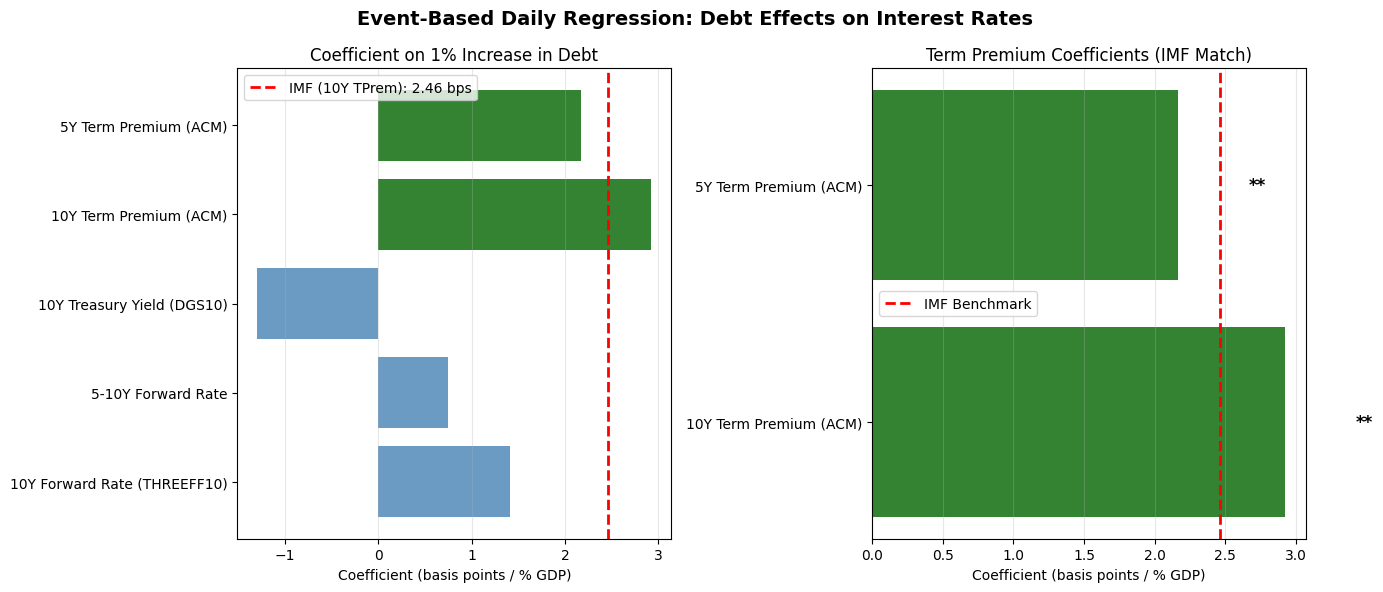

✓ Visualization saved to figures/event_based_regression_results.png


In [22]:
# Create comparison visualization: Event-based coefficients vs IMF
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Event-Based Daily Regression: Debt Effects on Interest Rates', fontsize=14, fontweight='bold')

# Chart 1: All dependent variables (Debt coefficient)
ax = axes[0]
dep_order = ['threeff10', 'fwd_5_10y', 'dgs10', 'acmtp10', 'acmtp05']
coeffs = []
colors = []
labels = []

for dep_var in dep_order:
    key = f"{dep_var}_vs_debt_pct_GDP"
    if key in results_dict:
        res = results_dict[key]
        coeffs.append(res['coefficient'])
        labels.append(dependent_desc[dep_var])
        # Color term premiums differently
        colors.append('darkgreen' if 'acmtp' in dep_var else 'steelblue')

y_pos = np.arange(len(labels))
ax.barh(y_pos, np.array(coeffs) * 100, color=colors, alpha=0.8)  # *100 for basis points
ax.axvline(imf_debt_effect * 100, color='red', linestyle='--', linewidth=2, label=f'IMF (10Y TPrem): {imf_debt_effect*100:.2f} bps')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Coefficient (basis points / % GDP)')
ax.set_title('Coefficient on 1% Increase in Debt')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Chart 2: Term Premium results with significance indicators
ax = axes[1]
term_prem_deps = ['acmtp10', 'acmtp05']
term_coeffs = []
term_labels = []
term_pvalues = []

for dep_var in term_prem_deps:
    key = f"{dep_var}_vs_debt_pct_GDP"
    if key in results_dict:
        res = results_dict[key]
        term_coeffs.append(res['coefficient'] * 100)
        term_labels.append(dependent_desc[dep_var])
        term_pvalues.append(res['p_value'])

y_pos = np.arange(len(term_labels))
bars = ax.barh(y_pos, term_coeffs, color='darkgreen', alpha=0.8)

# Add error markers for significance
for i, (coeff, pval) in enumerate(zip(term_coeffs, term_pvalues)):
    sig_marker = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
    ax.text(coeff + 0.5, i, sig_marker, va='center', fontsize=12, fontweight='bold')

ax.axvline(imf_debt_effect * 100, color='red', linestyle='--', linewidth=2, label='IMF Benchmark')
ax.set_yticks(y_pos)
ax.set_yticklabels(term_labels)
ax.set_xlabel('Coefficient (basis points / % GDP)')
ax.set_title('Term Premium Coefficients (IMF Match)')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/event_based_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to figures/event_based_regression_results.png")

## Summary & Key Findings

### What this notebook currently implements

**Event-based daily block:**
- First-trading-day-after matching
- Dependent variables: `THREEFF10`, `fwd_5_10y`, `DGS10`, `ACMTP05`, `ACMTP10`
- Fiscal regressors: debt, deficit, fiscal balance, and primary balance
- Specification: fiscal variable + linear/quadratic time trends (HAC standard errors)

**Quarterly M1–M4 block:**
- M1: fiscal + trends baseline
- M2–M4: adds controls (`TB3MS`, `real_gdp_growth`, `foreign_holdings_share`, `excess_bond_premium`, `pop_growth`, `recession_dummy`) when available

### Clarification vs older text

- Controls are **implemented in the quarterly M2–M4 models**.
- Controls are **not included** in the event-based daily regressions in the current specification.
- Primary balance is included in the event-based fiscal variable set.
- Sample sizes and coefficients should be read from the latest printed outputs/figures, not fixed narrative constants.

## Quarterly M1–M4 Models (IMF Specification)

This section provides the quarterly M1–M4 outputs in a notebook-only workflow.

- If a full quarterly control panel exists at `data/data_quarterly/quarterly_controls_panel.csv`, models are re-estimated directly in this notebook.
- Otherwise, the notebook uses the validated regression outputs already stored in `results/quarterly_regression_results.csv`.

This avoids synthetic controls and keeps results methodologically consistent.

## Build Quarterly Control Panel (Auto-Download)

This block builds `data/data_quarterly/quarterly_controls_panel.csv` directly from source data:

- Local fiscal release panel (`fiscal_5y_all_releases_panel.csv`)
- Local market-rate series (`DGS10`, `GSW` forward-rate table, `ACM` term premia)
- FRED controls (`TB3MS`, `GDPC1`, `USRECQ`, and debt-share components when available)

If some FRED series are unavailable, the script keeps the column but leaves missing values (no synthetic fillers).

In [23]:
from pathlib import Path

panel_out = Path('data/data_quarterly/quarterly_controls_panel.csv')


def _to_num(df, col):
    out = df.copy()
    out[col] = pd.to_numeric(out[col], errors='coerce')
    return out


def _load_fred(series_id, start='1970-01-01'):
    try:
        url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
        s = pd.read_csv(url)
        s = s.rename(columns={'DATE': 'observation_date'})
        if series_id not in s.columns:
            raise ValueError(f'FRED series column {series_id} not found in response')

        s['observation_date'] = pd.to_datetime(s['observation_date'], errors='coerce')
        s[series_id] = pd.to_numeric(s[series_id], errors='coerce')
        s = s.dropna(subset=['observation_date'])

        # Apply start filter to preserve previous behavior
        s = s[s['observation_date'] >= pd.to_datetime(start)]
        return s[['observation_date', series_id]]
    except Exception as err:
        print(f'FRED unavailable for {series_id}: {err}')
        return pd.DataFrame(columns=['observation_date', series_id])


def _prep_asof(df):
    out = df.copy()
    if 'observation_date' not in out.columns:
        return pd.DataFrame(columns=['observation_date'])
    out['observation_date'] = pd.to_datetime(out['observation_date'], errors='coerce')
    out = out.dropna(subset=['observation_date'])
    out = out.sort_values('observation_date')
    out = out.drop_duplicates(subset=['observation_date'], keep='last')
    return out


# 1) Base panel of CBO release dates
fiscal = pd.read_csv('data/data_quarterly/fiscal_5y_all_releases_panel.csv')
fiscal['observation_date'] = pd.to_datetime(fiscal['baseline_date'])
fiscal = fiscal.sort_values('observation_date').reset_index(drop=True)
base = fiscal[['observation_date', 'deficit_pct_GDP']].copy()
base = _prep_asof(base)

# 2) CBO-sourced debt_pct_GDP (as-of carry of latest available CBO debt baseline)
debt_cbo = pd.read_csv('data/data_quarterly/debt_5y_with_gdp_all_releases.csv')
debt_cbo['observation_date'] = pd.to_datetime(debt_cbo['baseline_date'])
debt_cbo = debt_cbo[['observation_date', 'debt_pct_GDP']].dropna().sort_values('observation_date')
debt_cbo = _prep_asof(debt_cbo)

# 3) CBO-sourced 5Y real GDP growth proxy
# Uses CBO repo actual_GDP series and CBO 5-year horizon mapping from fiscal panel:
# growth = annualized((GDP_{t+5}/GDP_t)^(1/5)-1)
actual_gdp = pd.read_csv('data/cbo_data/input_data/actual_GDP.csv').rename(columns={'fiscal_year': 'year', 'GDP': 'gdp_level'})
actual_gdp['year'] = pd.to_numeric(actual_gdp['year'], errors='coerce')
actual_gdp['gdp_level'] = pd.to_numeric(actual_gdp['gdp_level'], errors='coerce')
actual_gdp = actual_gdp.dropna().copy()

growth_cbo = fiscal[['baseline_date', 'projected_fiscal_year', 'GDP']].copy()
growth_cbo['observation_date'] = pd.to_datetime(growth_cbo['baseline_date'])
growth_cbo['projected_fiscal_year'] = pd.to_numeric(growth_cbo['projected_fiscal_year'], errors='coerce')
growth_cbo['GDP'] = pd.to_numeric(growth_cbo['GDP'], errors='coerce')
growth_cbo['base_year'] = growth_cbo['projected_fiscal_year'] - 5

growth_cbo = growth_cbo.merge(actual_gdp[['year', 'gdp_level']], left_on='base_year', right_on='year', how='left')
growth_cbo['real_gdp_growth'] = 100 * ((growth_cbo['GDP'] / growth_cbo['gdp_level']) ** (1 / 5) - 1)
growth_cbo = growth_cbo[['observation_date', 'real_gdp_growth']].dropna().sort_values('observation_date')
growth_cbo = _prep_asof(growth_cbo)

# 4) Local dependent variables
# T10_yield (DGS10)
dgs = pd.read_csv('data/data_quarterly/DGS10.csv')
dgs['observation_date'] = pd.to_datetime(dgs['observation_date'])
dgs = _to_num(dgs, 'DGS10').rename(columns={'DGS10': 'T10_yield'})
dgs = dgs[['observation_date', 'T10_yield']].dropna()
dgs = _prep_asof(dgs)

# Forward rates from GSW source (Federal Reserve)
gsw_panel = pd.read_csv('data/data_quarterly/gsw_forward_rates.csv')
gsw_panel['observation_date'] = pd.to_datetime(gsw_panel['observation_date'])
for col in ['fwd_5_10y', 'fwd_10_15y']:
    if col in gsw_panel.columns:
        gsw_panel[col] = pd.to_numeric(gsw_panel[col], errors='coerce')
ff = gsw_panel[['observation_date', 'fwd_5_10y', 'fwd_10_15y']].copy()
ff = _prep_asof(ff)

# tprem_5y / tprem_10y from ACM
acm = pd.read_excel('data/data_quarterly/ACMTermPremium.xlsx', sheet_name=0)
acm['observation_date'] = pd.to_datetime(acm['DATE'])
acm['tprem_5y'] = pd.to_numeric(acm['ACMTP05'], errors='coerce')
acm['tprem_10y'] = pd.to_numeric(acm['ACMTP10'], errors='coerce')
acm = acm[['observation_date', 'tprem_5y', 'tprem_10y']].dropna()
acm = _prep_asof(acm)

# 5) Other controls
# TB3MS and recession from FRED
tb3 = _prep_asof(_load_fred('TB3MS', '1970-01-01').rename(columns={'TB3MS': 'TB3MS'}))
rec = _prep_asof(_load_fred('USRECQ', '1970-01-01').rename(columns={'USRECQ': 'recession_dummy'}))

# Population growth proxy from CNP16OV
pop = _load_fred('CNP16OV', '1970-01-01')
if not pop.empty:
    pop = pop.sort_values('observation_date')
    pop['pop_growth'] = 100 * (pop['CNP16OV'] / pop['CNP16OV'].shift(12) - 1)
    pop = pop[['observation_date', 'pop_growth']]
else:
    pop = pd.DataFrame(columns=['observation_date', 'pop_growth'])
pop = _prep_asof(pop)

# Foreign holdings share proxy if both components available
foreign_num = _load_fred('FDHBFRBN', '1970-01-01')
foreign_den = _load_fred('GFDEBTN', '1970-01-01')
if (not foreign_num.empty) and (not foreign_den.empty):
    fshare = foreign_num.merge(foreign_den, on='observation_date', how='inner')
    fshare['foreign_holdings_share'] = 100 * fshare['FDHBFRBN'] / fshare['GFDEBTN']
    fshare = fshare[['observation_date', 'foreign_holdings_share']]
else:
    fshare = pd.DataFrame(columns=['observation_date', 'foreign_holdings_share'])
fshare = _prep_asof(fshare)

# EBP from Federal Reserve direct CSV (preferred)
try:
    ebp = pd.read_csv('https://www.federalreserve.gov/econres/notes/feds-notes/ebp_csv.csv')
    ebp['observation_date'] = pd.to_datetime(ebp['date'])
    ebp['excess_bond_premium'] = pd.to_numeric(ebp['ebp'], errors='coerce')
    ebp = ebp[['observation_date', 'excess_bond_premium']].dropna()
    ebp = _prep_asof(ebp)
except Exception as err:
    print(f'Fed EBP CSV unavailable: {err}')
    ebp = pd.DataFrame(columns=['observation_date', 'excess_bond_premium'])

# 6) As-of merge all series to CBO release dates
panel = base.copy()
for rhs in [debt_cbo, growth_cbo, dgs, ff, acm, tb3, rec, pop, fshare, ebp]:
    rhs = _prep_asof(rhs)
    if rhs.empty or len(rhs.columns) <= 1:
        continue
    panel = pd.merge_asof(panel, rhs, on='observation_date', direction='backward')

# Ensure expected control columns exist
for col in ['TB3MS', 'real_gdp_growth', 'foreign_holdings_share', 'excess_bond_premium', 'pop_growth', 'recession_dummy']:
    if col not in panel.columns:
        panel[col] = np.nan

# Ensure forward columns exist
for col in ['fwd_5_10y', 'fwd_10_15y']:
    if col not in panel.columns:
        panel[col] = np.nan

panel.to_csv(panel_out, index=False)

print(f'Saved quarterly panel to: {panel_out}')
print('Rows:', len(panel))
print('Non-missing counts:')
print(panel[['debt_pct_GDP', 'deficit_pct_GDP', 'T10_yield', 'fwd_5_10y', 'fwd_10_15y', 'tprem_5y', 'tprem_10y',
             'TB3MS', 'real_gdp_growth', 'foreign_holdings_share', 'excess_bond_premium',
             'pop_growth', 'recession_dummy']].notna().sum())
panel.head()

FRED unavailable for TB3MS: HTTP Error 504: Gateway Time-out
FRED unavailable for USRECQ: HTTP Error 504: Gateway Time-out
FRED unavailable for CNP16OV: HTTP Error 504: Gateway Time-out
Fed EBP CSV unavailable: HTTP Error 403: Forbidden
Saved quarterly panel to: data\data_quarterly\quarterly_controls_panel.csv
Rows: 99
Non-missing counts:
debt_pct_GDP              99
deficit_pct_GDP           99
T10_yield                 99
fwd_5_10y                 77
fwd_10_15y                77
tprem_5y                  99
tprem_10y                 99
TB3MS                      0
real_gdp_growth           99
foreign_holdings_share    99
excess_bond_premium        0
pop_growth                 0
recession_dummy            0
dtype: int64


,observation_date,deficit_pct_GDP,debt_pct_GDP,real_gdp_growth,T10_yield,fwd_5_10y,fwd_10_15y,tprem_5y,tprem_10y,foreign_holdings_share,TB3MS,excess_bond_premium,pop_growth,recession_dummy
0,1984-02-01,-5.598856,45.071080,7.762006,11.64,11.810140,11.685900,2.971737,4.098590,0.010302,NaN,NaN,NaN,NaN
1,1985-02-01,-5.033076,45.349188,7.060793,11.29,11.432540,11.545200,2.935927,3.937696,0.009411,NaN,NaN,NaN,NaN
2,1986-02-01,-2.056639,39.516847,6.700301,9.08,9.884060,10.387920,2.392979,3.485210,0.009301,NaN,NaN,NaN,NaN
3,1987-02-01,-1.797060,40.783335,6.125811,7.18,8.029180,8.524140,1.709547,2.577103,0.008742,NaN,NaN,NaN,NaN
4,1988-03-01,-2.399003,42.080655,6.119546,8.15,9.044696,9.407011,2.192066,3.201641,0.008744,NaN,NaN,NaN,NaN


In [24]:
# EBP fallback loader (handles 403 by sending browser-like headers)
import io
import requests

panel_path = Path('data/data_quarterly/quarterly_controls_panel.csv')
if panel_path.exists():
    panel_fix = pd.read_csv(panel_path)
    if panel_fix['excess_bond_premium'].notna().sum() == 0:
        url = 'https://www.federalreserve.gov/econres/notes/feds-notes/ebp_csv.csv'
        headers = {
            'User-Agent': 'Mozilla/5.0',
            'Accept': 'text/csv,application/octet-stream,*/*',
            'Referer': 'https://www.federalreserve.gov/'
        }
        try:
            resp = requests.get(url, headers=headers, timeout=30)
            resp.raise_for_status()
            ebp_df = pd.read_csv(io.StringIO(resp.text))
            ebp_df['observation_date'] = pd.to_datetime(ebp_df['date'], errors='coerce')
            ebp_df['excess_bond_premium'] = pd.to_numeric(ebp_df['ebp'], errors='coerce')
            ebp_df = ebp_df[['observation_date', 'excess_bond_premium']].dropna().sort_values('observation_date')

            panel_fix['observation_date'] = pd.to_datetime(panel_fix['observation_date'], errors='coerce')
            panel_fix = panel_fix.sort_values('observation_date')

            panel_fix = pd.merge_asof(
                panel_fix.drop(columns=['excess_bond_premium']),
                ebp_df,
                on='observation_date',
                direction='backward'
            )

            panel_fix.to_csv(panel_path, index=False)
            print('EBP fallback succeeded. Non-missing EBP:', panel_fix['excess_bond_premium'].notna().sum())
        except Exception as e:
            print('EBP fallback still failed:', e)
    else:
        print('EBP already populated; fallback not needed.')
else:
    print('Panel file missing; run the build cell first.')

EBP fallback succeeded. Non-missing EBP: 99


In [25]:
from pathlib import Path
from statsmodels.stats.stattools import durbin_watson

quarterly_results_path = Path('results/quarterly_regression_results.csv')
quarterly_panel_path = Path('data/data_quarterly/quarterly_controls_panel.csv')

print('Quarterly M1–M4 pipeline')
print(f'- Controls panel present: {quarterly_panel_path.exists()}')
print(f'- Precomputed M1–M4 results present: {quarterly_results_path.exists()}')

Quarterly M1–M4 pipeline
- Controls panel present: True
- Precomputed M1–M4 results present: True


In [26]:
model_labels = {
    'M1': 'Model 1: Fiscal',
    'M2': 'Model 2: +Controls',
    'M3': 'Model 3: +t',
    'M4': 'Model 4: +t²',
}

if quarterly_panel_path.exists():
    panel_q = pd.read_csv(quarterly_panel_path)
    panel_q['observation_date'] = pd.to_datetime(panel_q['observation_date'])
    panel_q = panel_q.sort_values('observation_date').reset_index(drop=True)

    required_fiscal = ['debt_pct_GDP', 'deficit_pct_GDP']
    required_dep_candidates = ['T10_yield', 'fwd_5_10y', 'fwd_10_15y', 'tprem_5y', 'tprem_10y']
    controls_q = ['TB3MS', 'real_gdp_growth', 'foreign_holdings_share', 'excess_bond_premium', 'pop_growth', 'recession_dummy']

    missing_fiscal = [c for c in required_fiscal if c not in panel_q.columns]
    if missing_fiscal:
        raise ValueError(f'Missing fiscal columns in quarterly_controls_panel.csv: {missing_fiscal}')

    dep_vars_q = [c for c in required_dep_candidates if c in panel_q.columns and panel_q[c].notna().sum() >= 20]
    if len(dep_vars_q) == 0:
        raise ValueError('No dependent variables with >=20 non-missing observations in quarterly_controls_panel.csv')

    panel_q['t'] = np.arange(1, len(panel_q) + 1)
    panel_q['t_squared'] = panel_q['t'] ** 2

    fiscal_vars_q = ['debt_pct_GDP', 'deficit_pct_GDP']
    rows = []

    for dep in dep_vars_q:
        for fiscal in fiscal_vars_q:
            # M1: fiscal + t + t²
            m1 = panel_q[[dep, fiscal, 't', 't_squared']].dropna()
            if len(m1) >= 20:
                y = m1[dep].values
                X = add_constant(m1[[fiscal, 't', 't_squared']].values)
                r = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
                rows.append({
                    'dependent_var': dep,
                    'fiscal_var': fiscal,
                    'model': model_labels['M1'],
                    'coef': r.params[1],
                    'stderr': r.bse[1],
                    'tstat': r.tvalues[1],
                    'pval': r.pvalues[1],
                    'r2': r.rsquared,
                    'durbin_watson': durbin_watson(r.resid),
                    'n_obs': len(m1),
                })

            # M2/M3/M4 ladder; use only controls that actually exist
            available_controls = [c for c in controls_q if c in panel_q.columns]
            m_all_cols = [dep, fiscal, 't', 't_squared'] + available_controls
            m_all = panel_q[m_all_cols].dropna()

            if len(m_all) >= 20 and len(available_controls) > 0:
                specs = {
                    'M2': [fiscal] + available_controls,
                    'M3': [fiscal] + available_controls + ['t'],
                    'M4': [fiscal] + available_controls + ['t', 't_squared'],
                }
                for key, rhs in specs.items():
                    y = m_all[dep].values
                    X = add_constant(m_all[rhs].values)
                    r = OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
                    rows.append({
                        'dependent_var': dep,
                        'fiscal_var': fiscal,
                        'model': model_labels[key],
                        'coef': r.params[1],
                        'stderr': r.bse[1],
                        'tstat': r.tvalues[1],
                        'pval': r.pvalues[1],
                        'r2': r.rsquared,
                        'durbin_watson': durbin_watson(r.resid),
                        'n_obs': len(m_all),
                    })

    quarterly_results = pd.DataFrame(rows)
    print(f'Re-estimated M1–M4 from controls panel: {len(quarterly_results)} rows')
    print('Dependent variables used:', dep_vars_q)
else:
    if not quarterly_results_path.exists():
        raise FileNotFoundError('Need either data/data_quarterly/quarterly_controls_panel.csv or results/quarterly_regression_results.csv')
    quarterly_results = pd.read_csv(quarterly_results_path)
    print(f'Loaded validated M1–M4 results: {len(quarterly_results)} rows')

quarterly_results.head()

Re-estimated M1–M4 from controls panel: 10 rows
Dependent variables used: ['T10_yield', 'fwd_5_10y', 'fwd_10_15y', 'tprem_5y', 'tprem_10y']


,dependent_var,fiscal_var,model,coef,stderr,tstat,pval,r2,durbin_watson,n_obs
0,T10_yield,debt_pct_GDP,Model 1: Fiscal,-0.016718,0.012198,-1.370484,0.170536,0.854339,0.530194,99
1,T10_yield,deficit_pct_GDP,Model 1: Fiscal,-0.008876,0.096226,-0.092238,0.926509,0.848512,0.492587,99
2,fwd_5_10y,debt_pct_GDP,Model 1: Fiscal,-0.001162,0.013592,-0.085495,0.931867,0.875061,0.581621,77
3,fwd_5_10y,deficit_pct_GDP,Model 1: Fiscal,-0.111213,0.093726,-1.186579,0.235394,0.880008,0.543534,77
4,fwd_10_15y,debt_pct_GDP,Model 1: Fiscal,0.007174,0.012926,0.554976,0.578911,0.872244,0.535822,77


In [27]:
dep_name_map = {
    'T10_yield': '10-Year Treasury Yield',
    'fwd_5_10y': '5-10 Year Forward Rate',
    'fwd_10_15y': '10-15 Year Forward Rate',
    'tprem_5y': '5-Year Term Premium',
    'tprem_10y': '10-Year Term Premium',
}
fiscal_name_map = {
    'debt_pct_GDP': 'Debt (% GDP)',
    'deficit_pct_GDP': 'Deficit (% GDP)',
}

quarterly_results['dependent_name'] = quarterly_results['dependent_var'].map(dep_name_map).fillna(quarterly_results['dependent_var'])
quarterly_results['fiscal_name'] = quarterly_results['fiscal_var'].map(fiscal_name_map).fillna(quarterly_results['fiscal_var'])

export_cols = [
    'dependent_var', 'dependent_name', 'fiscal_var', 'fiscal_name',
    'model', 'coef', 'stderr', 'tstat', 'pval', 'r2', 'durbin_watson', 'n_obs'
]
quarterly_results_export = quarterly_results[export_cols].copy()
quarterly_results_export = quarterly_results_export.sort_values(['dependent_var', 'fiscal_var', 'model']).reset_index(drop=True)
quarterly_results_export.to_csv('results/quarterly_regression_results.csv', index=False)

print('Saved:', 'results/quarterly_regression_results.csv')
print('Shape:', quarterly_results_export.shape)
quarterly_results_export.head(10)

Saved: results/quarterly_regression_results.csv
Shape: (10, 12)


,dependent_var,dependent_name,fiscal_var,fiscal_name,model,coef,stderr,tstat,pval,r2,durbin_watson,n_obs
0,T10_yield,10-Year Treasury Yield,debt_pct_GDP,Debt (% GDP),Model 1: Fiscal,-0.016718,0.012198,-1.370484,0.170536,0.854339,0.530194,99
1,T10_yield,10-Year Treasury Yield,deficit_pct_GDP,Deficit (% GDP),Model 1: Fiscal,-0.008876,0.096226,-0.092238,0.926509,0.848512,0.492587,99
2,fwd_10_15y,10-15 Year Forward Rate,debt_pct_GDP,Debt (% GDP),Model 1: Fiscal,0.007174,0.012926,0.554976,0.578911,0.872244,0.535822,77
3,fwd_10_15y,10-15 Year Forward Rate,deficit_pct_GDP,Deficit (% GDP),Model 1: Fiscal,-0.139890,0.075186,-1.860577,0.062804,0.879777,0.514612,77
4,fwd_5_10y,5-10 Year Forward Rate,debt_pct_GDP,Debt (% GDP),Model 1: Fiscal,-0.001162,0.013592,-0.085495,0.931867,0.875061,0.581621,77
5,fwd_5_10y,5-10 Year Forward Rate,deficit_pct_GDP,Deficit (% GDP),Model 1: Fiscal,-0.111213,0.093726,-1.186579,0.235394,0.880008,0.543534,77
6,tprem_10y,10-Year Term Premium,debt_pct_GDP,Debt (% GDP),Model 1: Fiscal,0.018311,0.013131,1.394501,0.163166,0.651822,0.373574,99
7,tprem_10y,10-Year Term Premium,deficit_pct_GDP,Deficit (% GDP),Model 1: Fiscal,-0.207979,0.072642,-2.863080,0.004195,0.686735,0.397668,99
8,tprem_5y,5-Year Term Premium,debt_pct_GDP,Debt (% GDP),Model 1: Fiscal,0.013527,0.009866,1.371033,0.170365,0.655789,0.421412,99
9,tprem_5y,5-Year Term Premium,deficit_pct_GDP,Deficit (% GDP),Model 1: Fiscal,-0.167280,0.054072,-3.093647,0.001977,0.698639,0.442984,99


In [28]:
# Compact regression table (coef with significance stars)
def star(p):
    return '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))

display_table = quarterly_results_export.copy()
display_table['coef_fmt'] = display_table.apply(lambda r: f"{r['coef']:.4f}{star(r['pval'])}", axis=1)

pivot = display_table.pivot_table(
    index=['fiscal_name', 'model'],
    columns='dependent_name',
    values='coef_fmt',
    aggfunc='first'
)

print('M1–M4 coefficient table (stars by p-value):')
pivot

M1–M4 coefficient table (stars by p-value):


,dependent_name,10-15 Year Forward Rate,10-Year Term Premium,10-Year Treasury Yield,5-10 Year Forward Rate,5-Year Term Premium
fiscal_name,model,,,,,
Debt (% GDP),Model 1: Fiscal,0.0072,0.0183,-0.0167,-0.0012,0.0135
Deficit (% GDP),Model 1: Fiscal,-0.1399*,-0.2080***,-0.0089,-0.1112,-0.1673***


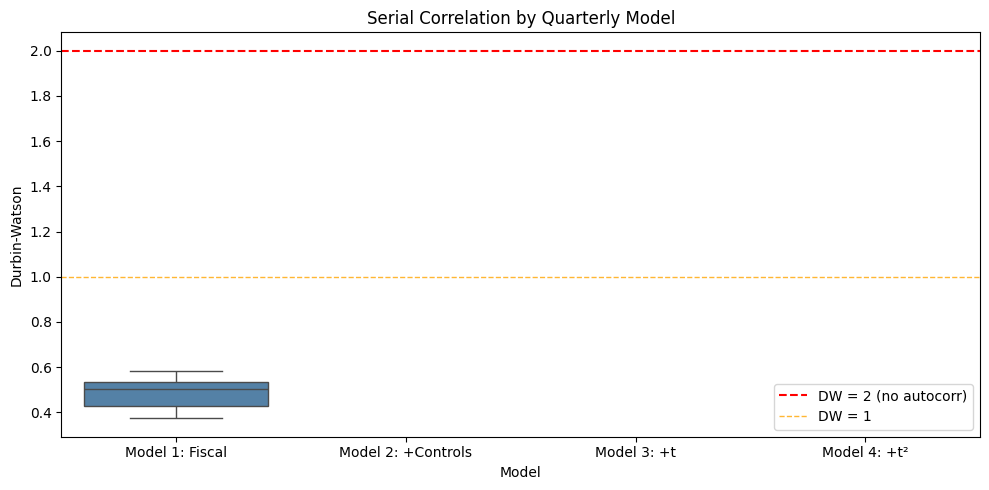

Saved: figures/durbin_watson_by_model.png


,count,mean,std,min,max
model,,,,,
Model 1: Fiscal,10,0.483401,0.070038,0.373574,0.581621


In [29]:
# Durbin-Watson diagnostics plot
plt.figure(figsize=(10, 5))
order = ['Model 1: Fiscal', 'Model 2: +Controls', 'Model 3: +t', 'Model 4: +t²']
plot_df = quarterly_results_export.copy()
plot_df['model'] = pd.Categorical(plot_df['model'], categories=order, ordered=True)
plot_df = plot_df.sort_values('model')

sns.boxplot(data=plot_df, x='model', y='durbin_watson', color='steelblue')
plt.axhline(2.0, color='red', linestyle='--', linewidth=1.5, label='DW = 2 (no autocorr)')
plt.axhline(1.0, color='orange', linestyle='--', linewidth=1.0, alpha=0.8, label='DW = 1')
plt.ylabel('Durbin-Watson')
plt.xlabel('Model')
plt.title('Serial Correlation by Quarterly Model')
plt.legend()
plt.tight_layout()
plt.savefig('figures/durbin_watson_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved:', 'figures/durbin_watson_by_model.png')
plot_df.groupby('model')['durbin_watson'].agg(['count', 'mean', 'std', 'min', 'max'])

## Extended Descriptive Outputs

This section prints detailed descriptive outputs for:
- Variable inventory and data coverage
- Event-study sample statistics
- Quarterly panel statistics
- Regression-result summaries
- Missingness diagnostics

In [30]:
from pathlib import Path

print('\n' + '='*120)
print('EXTENDED DESCRIPTIVE OUTPUTS')
print('='*120)

# -----------------------------
# 1) Source file inventory
# -----------------------------
print('\n[1] SOURCE FILE INVENTORY')
source_files = {
    'debt_5y': Path('data/data_quarterly/debt_5y_with_gdp_all_releases.csv'),
    'deficit_5y': Path('data/data_quarterly/deficit_5y_with_gdp_all_releases.csv'),
    'fiscal_balance_5y': Path('data/data_quarterly/fiscal_balance_5y_with_gdp_all_releases.csv'),
    'primary_balance_5y': Path('data/data_quarterly/primary_balance_5y_with_gdp_all_releases.csv'),
    'THREEFF5': Path('data/data_quarterly/THREEFF5.csv'),
    'THREEFF6': Path('data/data_quarterly/THREEFF6.csv'),
    'THREEFF7': Path('data/data_quarterly/THREEFF7.csv'),
    'THREEFF8': Path('data/data_quarterly/THREEFF8.csv'),
    'THREEFF9': Path('data/data_quarterly/THREEFF9.csv'),
    'THREEFF10': Path('data/data_quarterly/THREEFF10.csv'),
    'DGS10': Path('data/data_quarterly/DGS10.csv'),
    'quarterly_controls_panel': Path('data/data_quarterly/quarterly_controls_panel.csv'),
    'quarterly_results': Path('results/quarterly_regression_results.csv'),
}

for name, path in source_files.items():
    if not path.exists():
        print(f'  - {name:<26} MISSING ({path})')
        continue

    if path.suffix.lower() == '.csv':
        df_tmp = pd.read_csv(path)
        date_cols = [c for c in ['observation_date', 'baseline_date', 'DATE'] if c in df_tmp.columns]
        date_span = ''
        if date_cols:
            dcol = date_cols[0]
            dser = pd.to_datetime(df_tmp[dcol], errors='coerce').dropna()
            if len(dser) > 0:
                date_span = f" | {dcol}: {dser.min().date()} to {dser.max().date()}"
        print(f"  - {name:<26} rows={len(df_tmp):>6} cols={len(df_tmp.columns):>3}{date_span}")
    else:
        print(f'  - {name:<26} found ({path.name})')

# -----------------------------
# 2) Event-study sample stats
# -----------------------------
print('\n[2] EVENT-STUDY SAMPLE STATISTICS')
if 'event_df_clean' in globals():
    event_vars = [
        'debt_pct_GDP', 'deficit_pct_GDP', 'fiscal_balance_pct_GDP', 'primary_balance_pct_GDP',
        'threeff10', 'fwd_5_10y', 'dgs10', 'acmtp10', 'acmtp05', 't', 't_squared'
    ]
    event_vars = [v for v in event_vars if v in event_df_clean.columns]

    print(f"  Observations: {len(event_df_clean)}")
    if 'cbo_date' in event_df_clean.columns and len(event_df_clean) > 0:
        dates = pd.to_datetime(event_df_clean['cbo_date'], errors='coerce').dropna()
        if len(dates) > 0:
            print(f"  Date range: {dates.min().date()} to {dates.max().date()}")

    evt_desc = event_df_clean[event_vars].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
    evt_desc['missing'] = event_df_clean[event_vars].isna().sum()
    evt_desc['missing_pct'] = 100 * evt_desc['missing'] / len(event_df_clean)
    print('\n  Variable descriptives (event sample):')
    print(evt_desc[['count', 'mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max', 'missing', 'missing_pct']].round(4).to_string())

    corr_vars = [v for v in ['debt_pct_GDP', 'deficit_pct_GDP', 'fiscal_balance_pct_GDP', 'primary_balance_pct_GDP', 'threeff10', 'fwd_5_10y', 'dgs10', 'acmtp10', 'acmtp05'] if v in event_df_clean.columns]
    if len(corr_vars) >= 2:
        print('\n  Correlation matrix (event variables):')
        print(event_df_clean[corr_vars].corr().round(3).to_string())
else:
    print('  event_df_clean not found in memory. Run earlier event cells first.')

# -----------------------------
# 3) Quarterly panel stats
# -----------------------------
print('\n[3] QUARTERLY PANEL STATISTICS')
panel_path = Path('data/data_quarterly/quarterly_controls_panel.csv')
if panel_path.exists():
    panel = pd.read_csv(panel_path)
    print(f'  Rows: {len(panel)}, Columns: {len(panel.columns)}')

    if 'observation_date' in panel.columns:
        p_dates = pd.to_datetime(panel['observation_date'], errors='coerce').dropna()
        if len(p_dates) > 0:
            print(f"  Date range: {p_dates.min().date()} to {p_dates.max().date()}")

    q_vars = [
        'debt_pct_GDP', 'deficit_pct_GDP', 'T10_yield', 'fwd_5_10y', 'fwd_10_15y', 'tprem_5y', 'tprem_10y',
        'TB3MS', 'real_gdp_growth', 'foreign_holdings_share', 'excess_bond_premium', 'pop_growth', 'recession_dummy'
    ]
    q_vars = [v for v in q_vars if v in panel.columns]

    q_desc = panel[q_vars].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T
    q_desc['missing'] = panel[q_vars].isna().sum()
    q_desc['missing_pct'] = 100 * q_desc['missing'] / len(panel)

    print('\n  Variable descriptives (quarterly panel):')
    print(q_desc[['count', 'mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max', 'missing', 'missing_pct']].round(4).to_string())
else:
    print('  quarterly_controls_panel.csv not found.')

# -----------------------------
# 4) Regression result summaries
# -----------------------------
print('\n[4] REGRESSION RESULT SUMMARIES')

if 'results_dict' in globals() and len(results_dict) > 0:
    event_rows = []
    for key, r in results_dict.items():
        event_rows.append({
            'key': key,
            'dep_var': r['dep_var'],
            'fiscal_var': r['fiscal_var'],
            'coef': r['coefficient'],
            'std_error': r['std_error'],
            'p_value': r['p_value'],
            'n_obs': r['n_obs'],
            'r_squared': r['r_squared']
        })
    event_res_df = pd.DataFrame(event_rows).sort_values(['dep_var', 'fiscal_var'])

    print('  Event-based regressions (full table):')
    print(event_res_df.round(6).to_string(index=False))

    print('\n  Event-based significance counts:')
    sig_counts = pd.Series({
        'p<0.01': (event_res_df['p_value'] < 0.01).sum(),
        'p<0.05': (event_res_df['p_value'] < 0.05).sum(),
        'p<0.10': (event_res_df['p_value'] < 0.10).sum(),
        'total': len(event_res_df)
    })
    print(sig_counts.to_string())
else:
    print('  results_dict not found in memory. Run event regression cells first.')

qres_path = Path('results/quarterly_regression_results.csv')
if qres_path.exists():
    qres = pd.read_csv(qres_path)
    print('\n  Quarterly M1–M4 results overview:')
    print(f"    Rows: {len(qres)} | Dep vars: {qres['dependent_var'].nunique()} | Fiscal vars: {qres['fiscal_var'].nunique()}")

    print('\n  Quarterly by model (mean coef, mean p-value, mean R², mean N):')
    q_model = qres.groupby('model').agg(
        mean_coef=('coef', 'mean'),
        mean_pval=('pval', 'mean'),
        mean_r2=('r2', 'mean'),
        mean_n=('n_obs', 'mean'),
        n_specs=('coef', 'count')
    ).round(4)
    print(q_model.to_string())

    print('\n  Quarterly significance counts:')
    q_sig = pd.Series({
        'p<0.01': (qres['pval'] < 0.01).sum(),
        'p<0.05': (qres['pval'] < 0.05).sum(),
        'p<0.10': (qres['pval'] < 0.10).sum(),
        'total': len(qres)
    })
    print(q_sig.to_string())
else:
    print('  quarterly_regression_results.csv not found.')

print('\n' + '='*120)
print('END OF EXTENDED DESCRIPTIVE OUTPUTS')
print('='*120)


EXTENDED DESCRIPTIVE OUTPUTS

[1] SOURCE FILE INVENTORY
  - debt_5y                    rows=    44 cols=  5 | baseline_date: 1984-02-01 to 2025-01-01
  - deficit_5y                 rows=    99 cols=  5 | baseline_date: 1984-02-01 to 2025-01-01
  - fiscal_balance_5y          rows=    99 cols=  5 | baseline_date: 1984-02-01 to 2025-01-01
  - primary_balance_5y         rows=    87 cols=  5 | baseline_date: 1992-01-01 to 2025-01-01
  - THREEFF5                   rows=  9024 cols=  2 | observation_date: 1990-01-02 to 2026-02-27
  - THREEFF6                   rows=  9024 cols=  2 | observation_date: 1990-01-02 to 2026-02-27
  - THREEFF7                   rows=  9024 cols=  2 | observation_date: 1990-01-02 to 2026-02-27
  - THREEFF8                   rows=  9024 cols=  2 | observation_date: 1990-01-02 to 2026-02-27
  - THREEFF9                   rows=  9024 cols=  2 | observation_date: 1990-01-02 to 2026-02-27
  - THREEFF10                  rows=  9024 cols=  2 | observation_date: 1990-01-02

## Descriptive PNG Outputs

This section saves comprehensive descriptive figures to `figures/` for reporting.

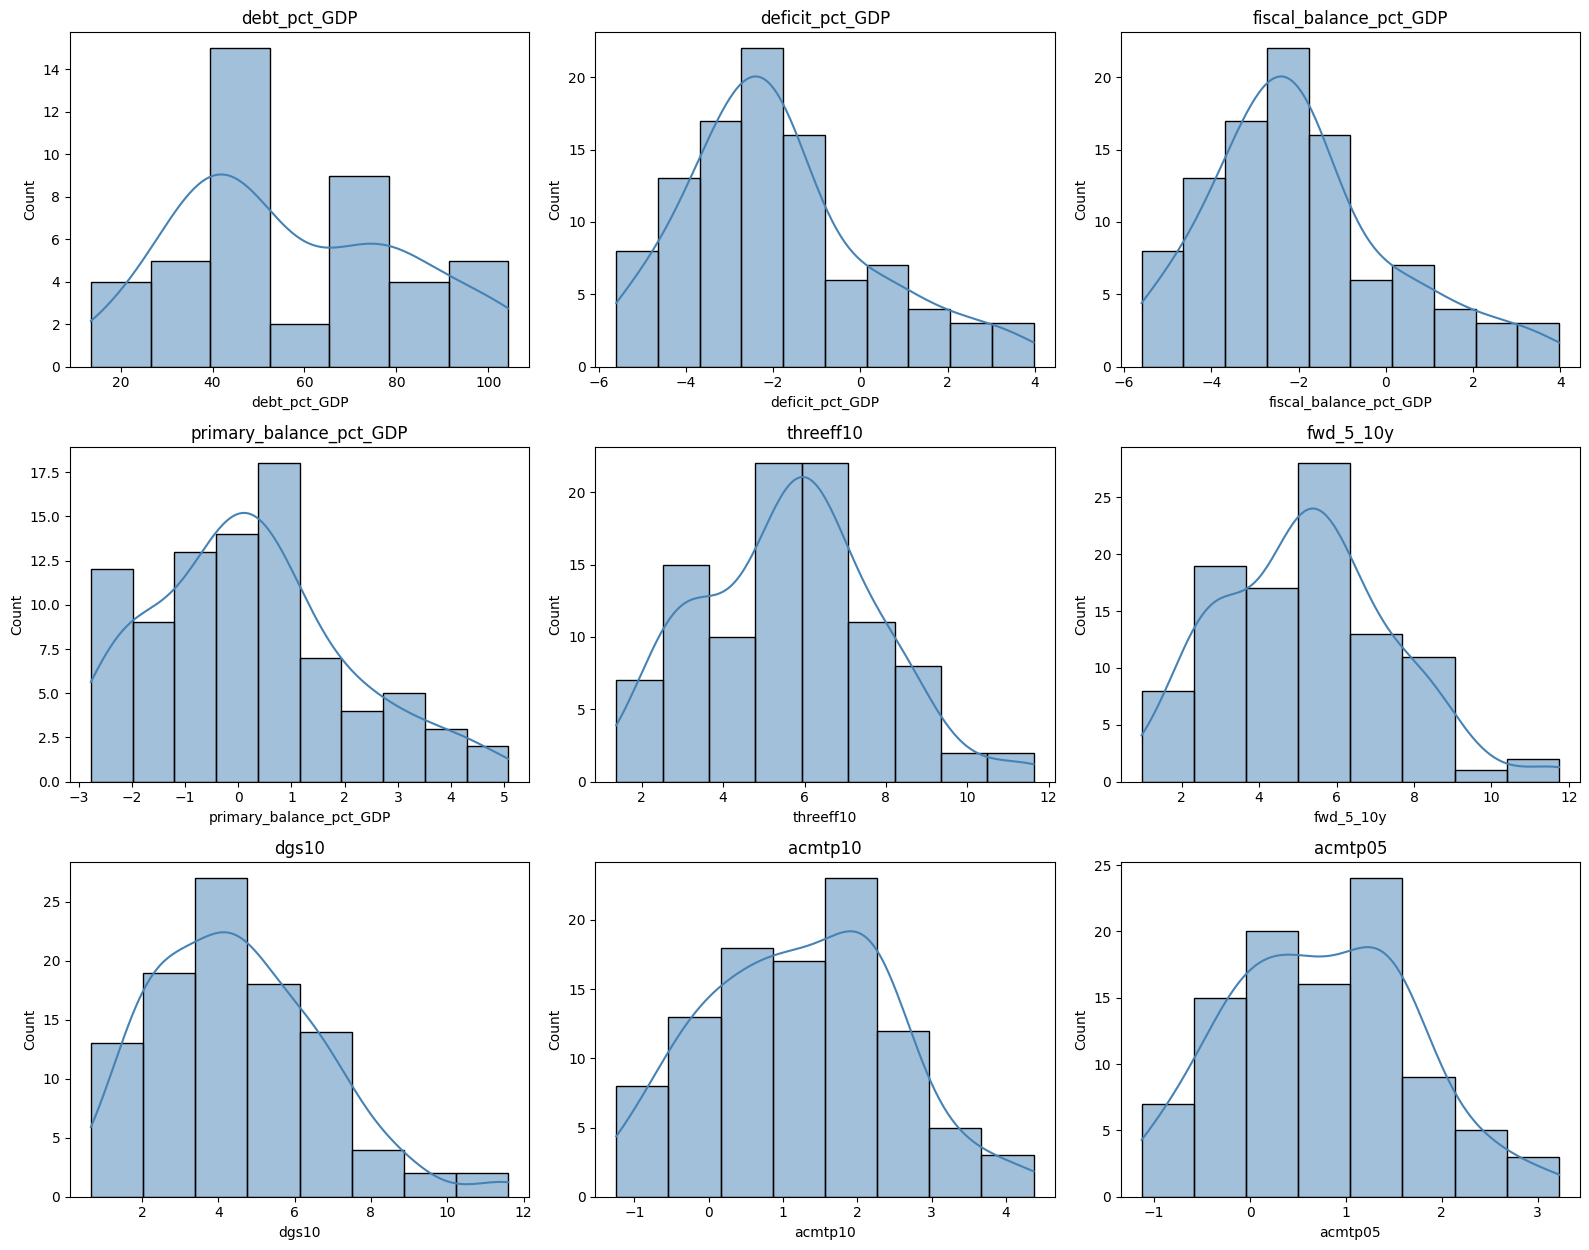

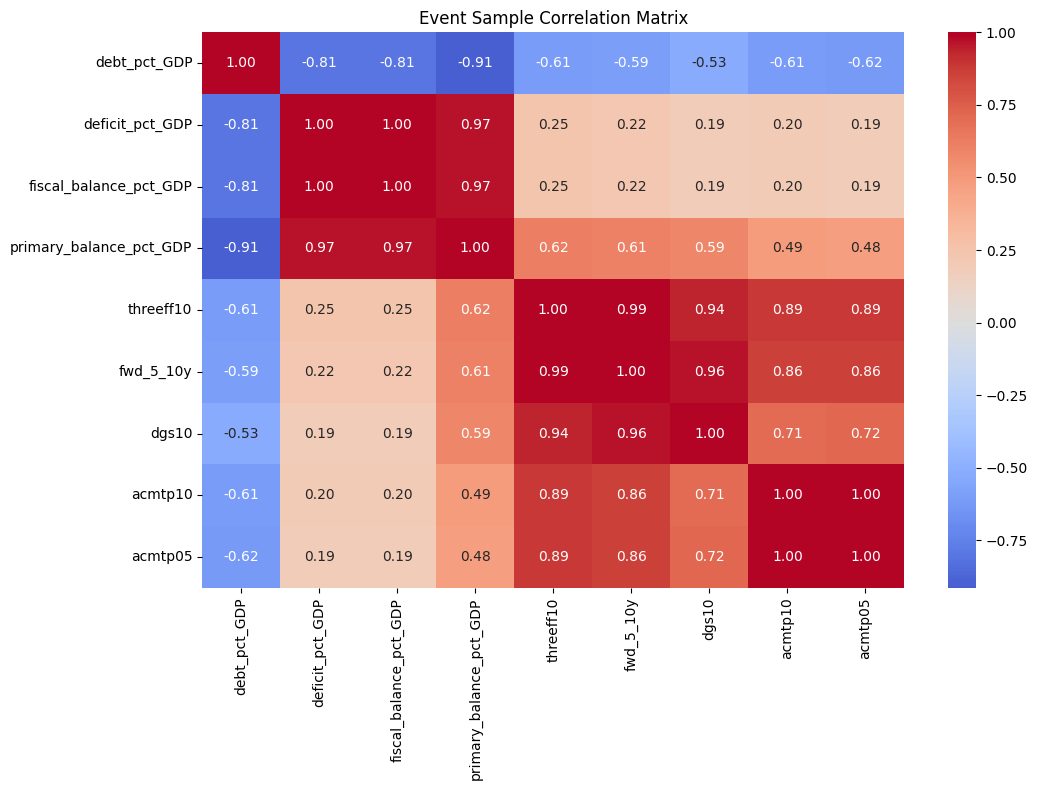

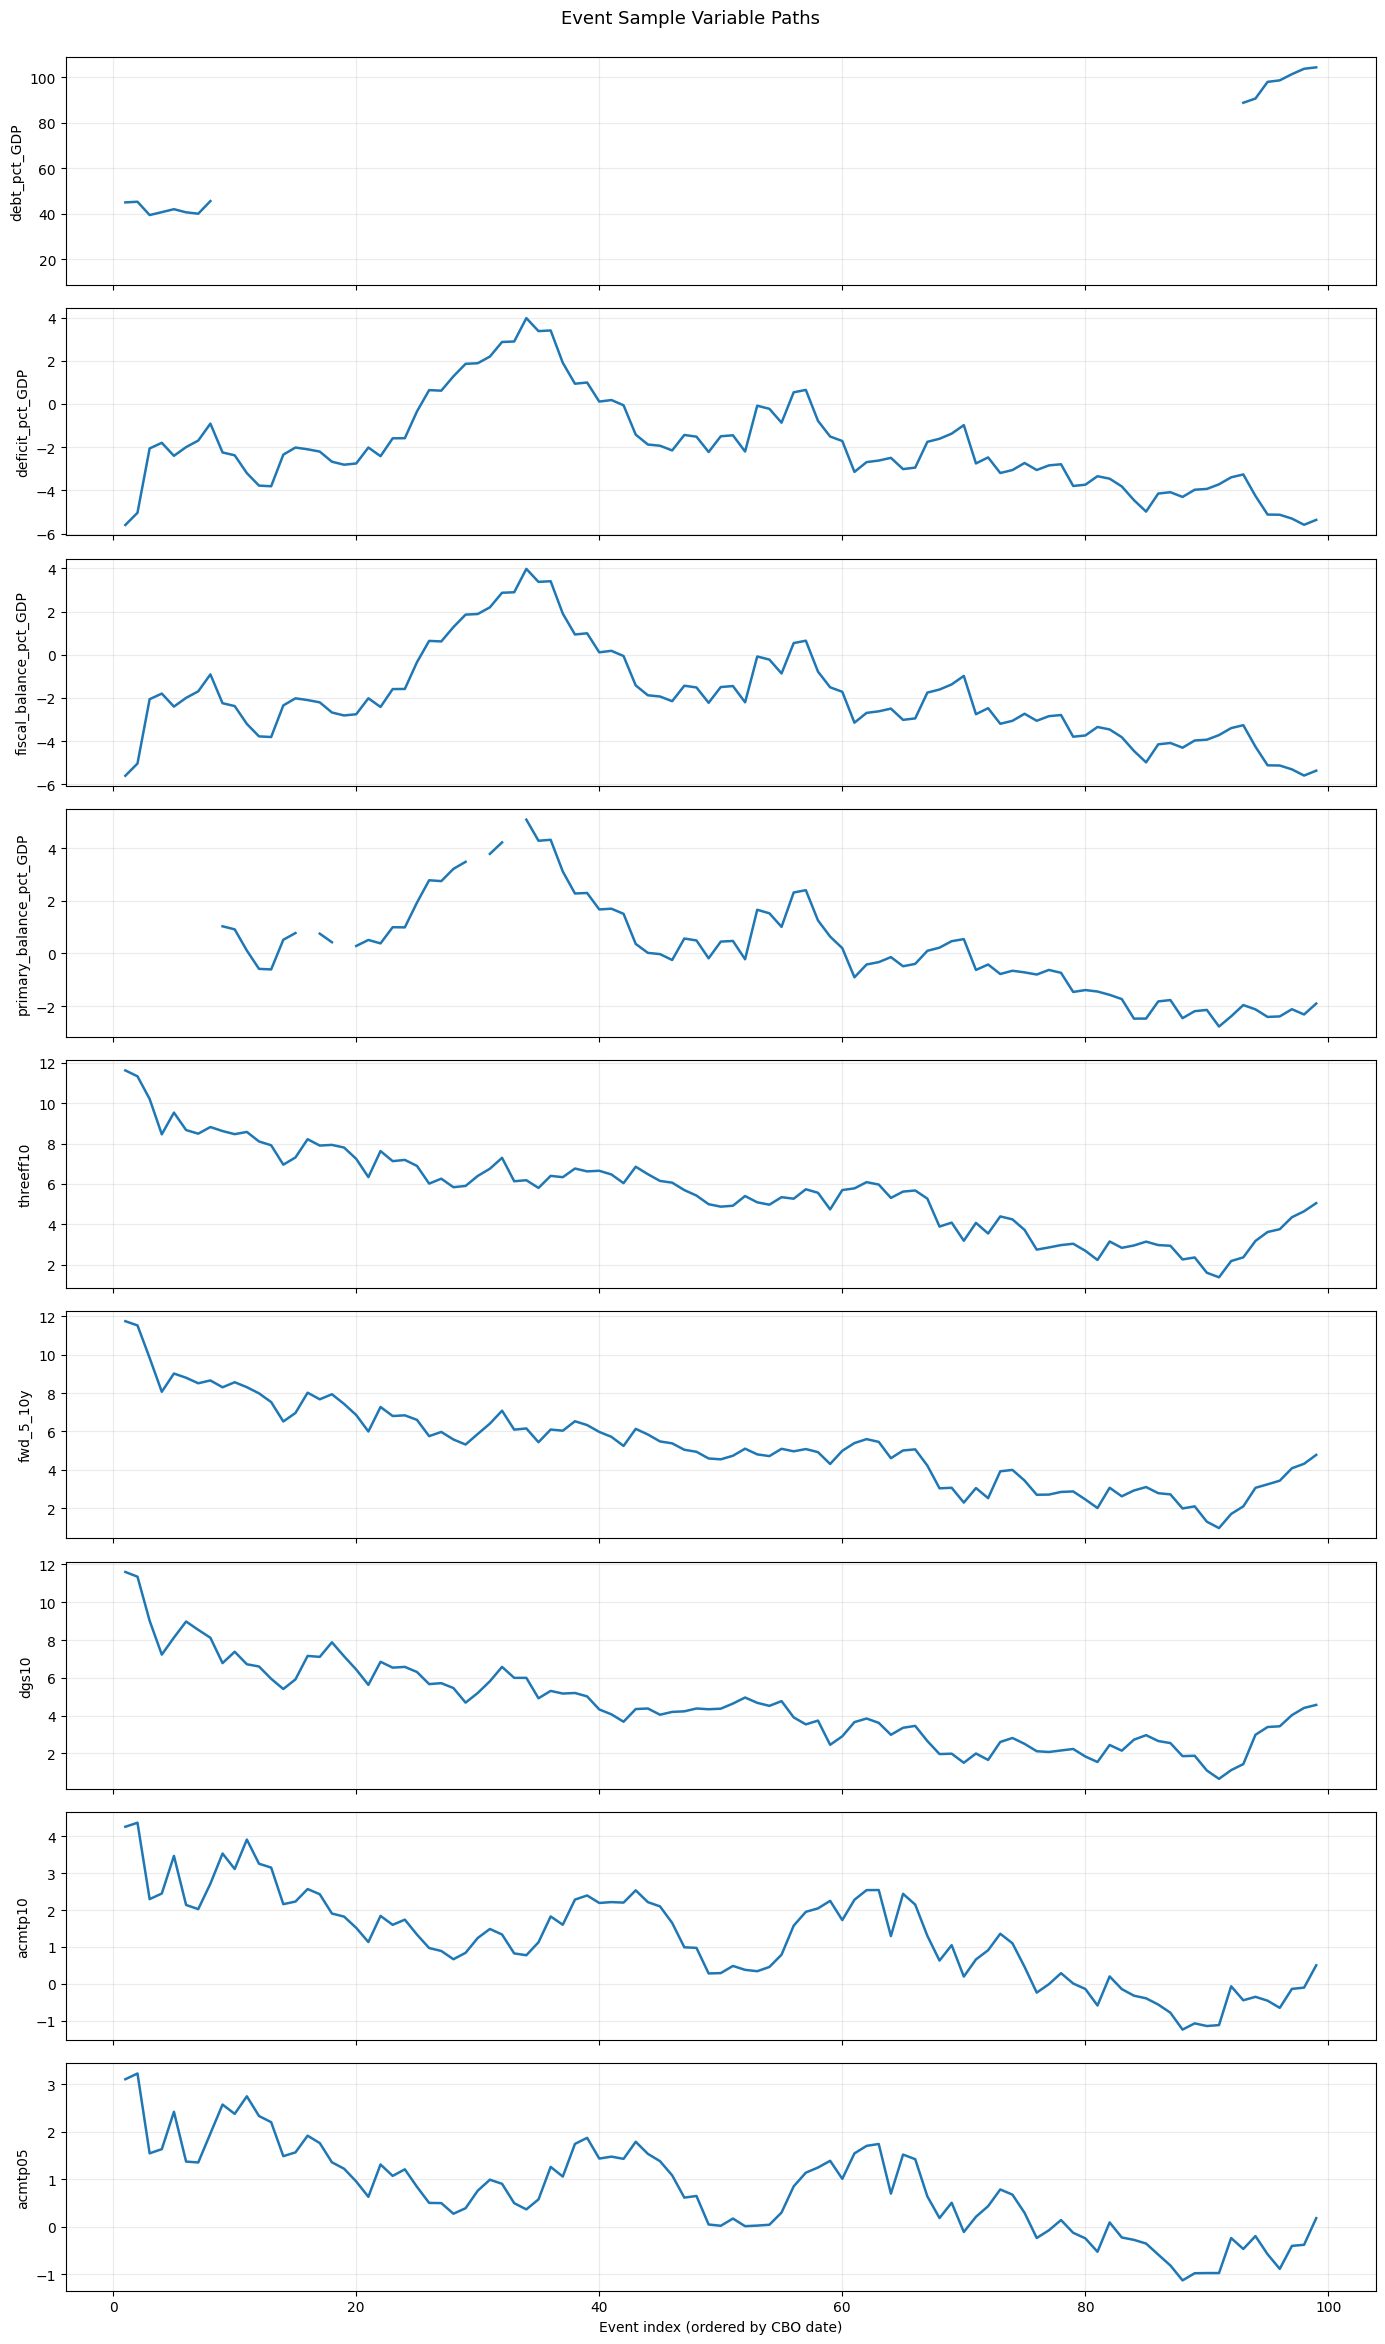

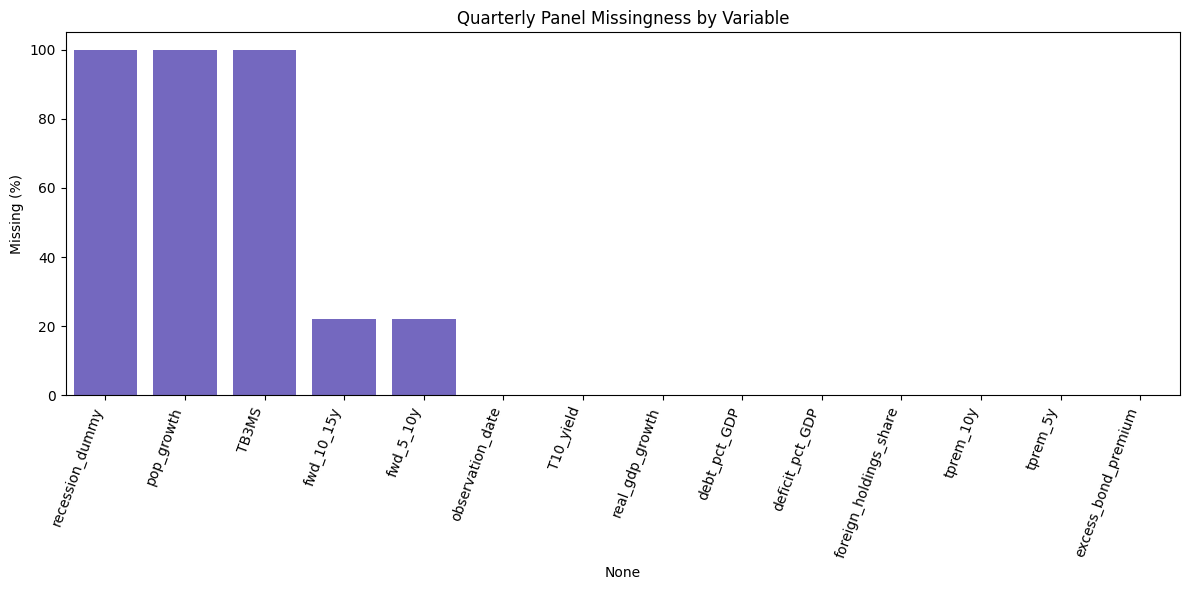

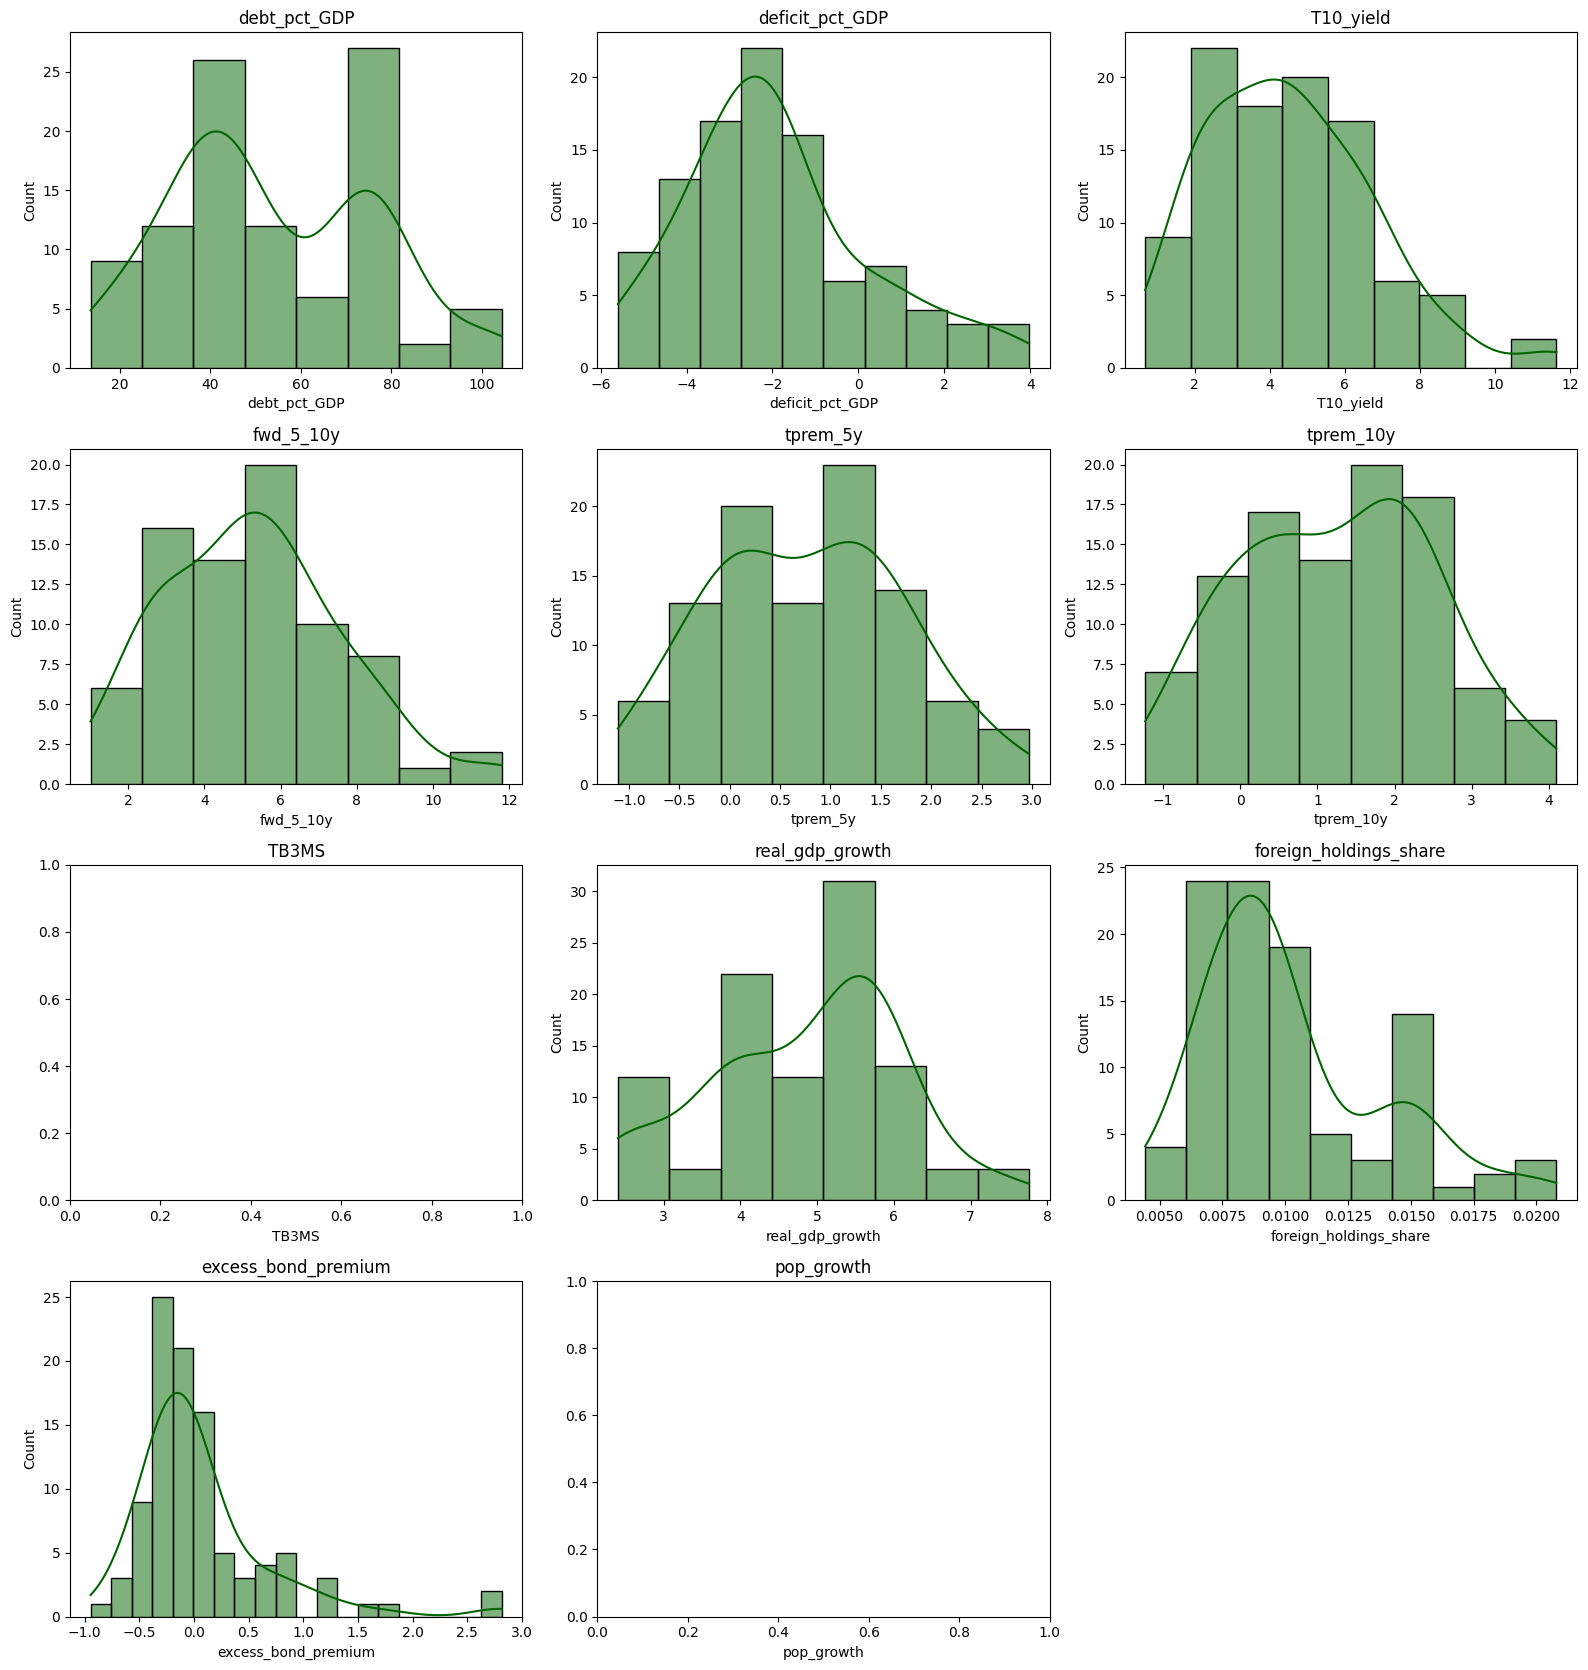

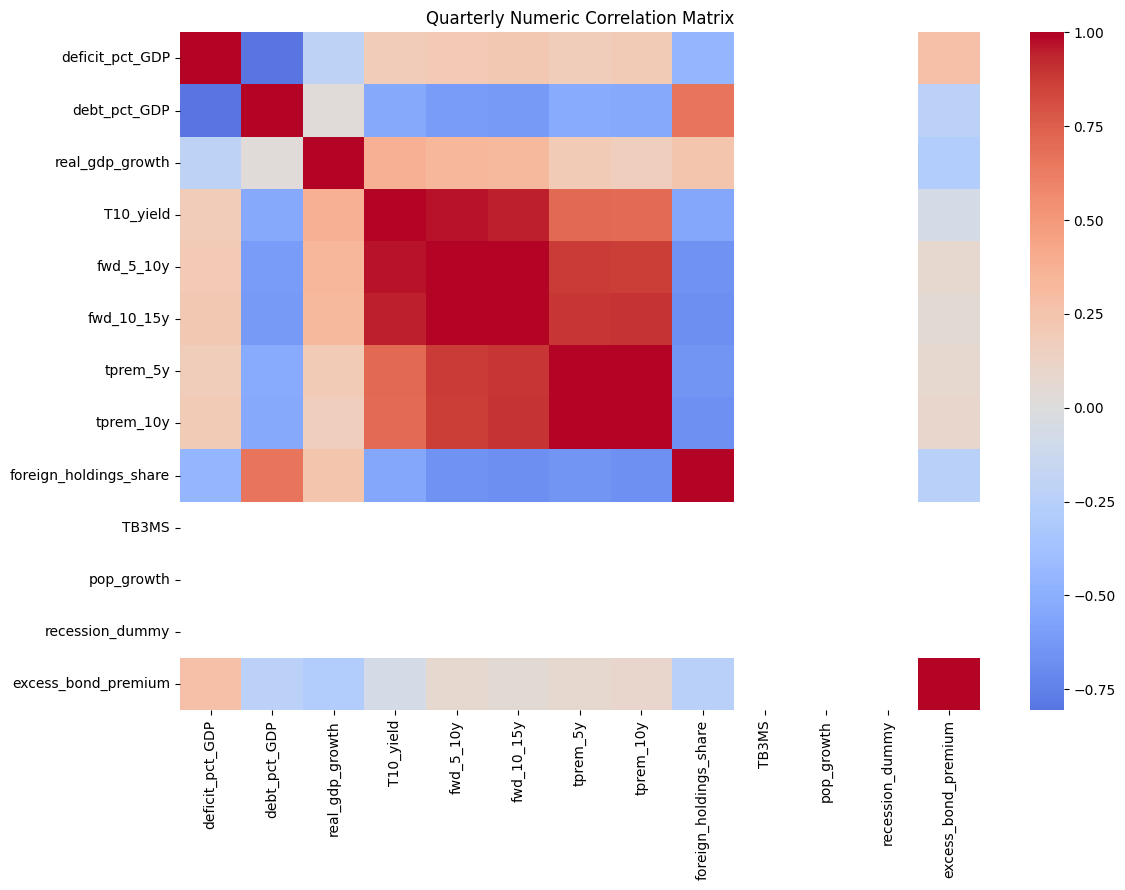

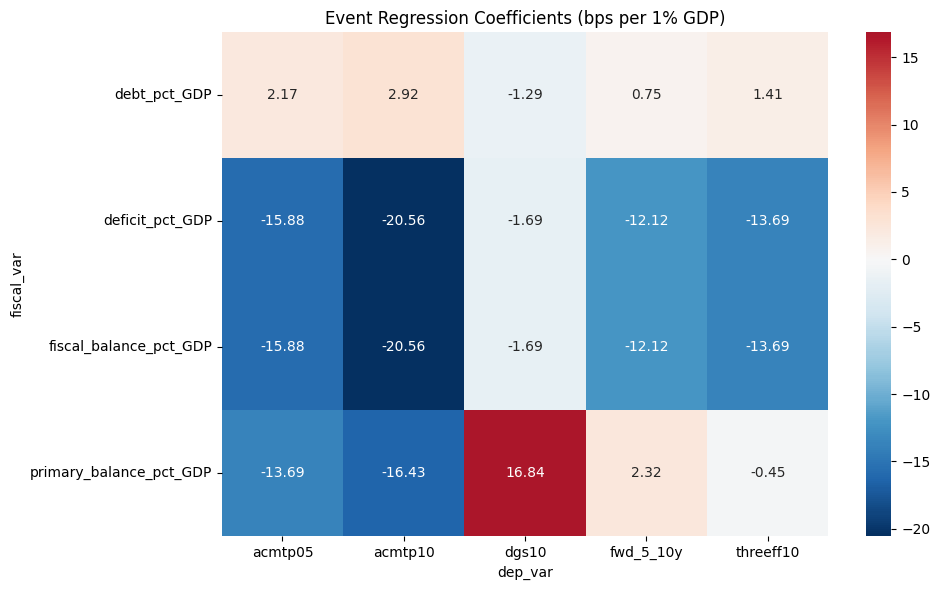

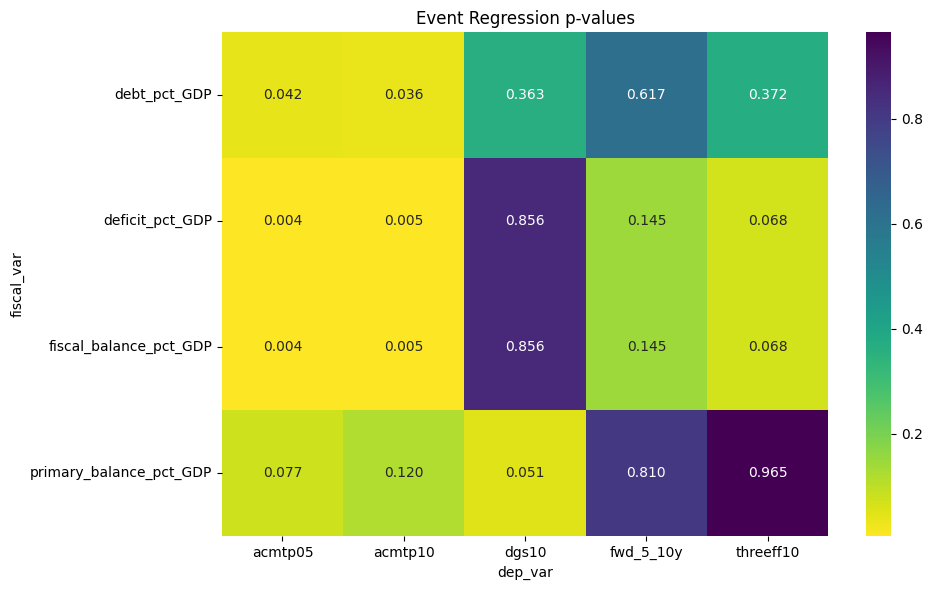


Saved descriptive PNG files in figures/:
  - desc_event_coef_heatmap.png
  - desc_event_correlation_heatmap.png
  - desc_event_distributions.png
  - desc_event_pvalue_heatmap.png
  - desc_event_variable_paths.png
  - desc_event_variable_paths_nonmissing.png
  - desc_quarterly_correlation_heatmap.png
  - desc_quarterly_distributions.png
  - desc_quarterly_missingness.png
  - durbin_watson_by_model.png
  - event_based_regression_results.png
  - event_fiscal_coefficients_comparison.png
  - model_fit_rsquared_comparison.png
  - quarterly_m1m4_coefficients.png


In [31]:
from pathlib import Path

fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# 1) Event sample distributions
if 'event_df_clean' in globals() and len(event_df_clean) > 0:
    event_plot_vars = [
        'debt_pct_GDP', 'deficit_pct_GDP', 'fiscal_balance_pct_GDP', 'primary_balance_pct_GDP',
        'threeff10', 'fwd_5_10y', 'dgs10', 'acmtp10', 'acmtp05'
    ]
    event_plot_vars = [v for v in event_plot_vars if v in event_df_clean.columns]

    ncols = 3
    nrows = int(np.ceil(len(event_plot_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(event_plot_vars):
        ax = axes[i]
        sns.histplot(event_df_clean[var].dropna(), kde=True, ax=ax, color='steelblue')
        ax.set_title(var)
        ax.set_xlabel(var)

    for j in range(len(event_plot_vars), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(fig_dir / 'desc_event_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 2) Event correlation heatmap
    plt.figure(figsize=(11, 8))
    corr = event_df_clean[event_plot_vars].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Event Sample Correlation Matrix')
    plt.tight_layout()
    plt.savefig(fig_dir / 'desc_event_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 3) Event fiscal/rate over release index
    plot_vars = [v for v in ['debt_pct_GDP', 'deficit_pct_GDP', 'fiscal_balance_pct_GDP', 'primary_balance_pct_GDP', 'threeff10', 'fwd_5_10y', 'dgs10', 'acmtp10', 'acmtp05'] if v in event_df_clean.columns]
    fig, axes = plt.subplots(len(plot_vars), 1, figsize=(14, 2.6 * len(plot_vars)), sharex=True)
    if len(plot_vars) == 1:
        axes = [axes]

    x = np.arange(1, len(event_df_clean) + 1)
    for ax, var in zip(axes, plot_vars):
        ax.plot(x, event_df_clean[var].values, linewidth=1.8)
        ax.set_ylabel(var)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel('Event index (ordered by CBO date)')
    fig.suptitle('Event Sample Variable Paths', y=1.0, fontsize=13)
    plt.tight_layout()
    plt.savefig(fig_dir / 'desc_event_variable_paths.png', dpi=300, bbox_inches='tight')
    plt.show()

# Quarterly panel plots
panel_path = Path('data/data_quarterly/quarterly_controls_panel.csv')
if panel_path.exists():
    panel = pd.read_csv(panel_path)

    # 4) Quarterly missingness bar chart
    miss_pct = panel.isna().mean().sort_values(ascending=False) * 100
    plt.figure(figsize=(12, 6))
    sns.barplot(x=miss_pct.index, y=miss_pct.values, color='slateblue')
    plt.xticks(rotation=70, ha='right')
    plt.ylabel('Missing (%)')
    plt.title('Quarterly Panel Missingness by Variable')
    plt.tight_layout()
    plt.savefig(fig_dir / 'desc_quarterly_missingness.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 5) Quarterly key variable distributions
    q_vars = [
        'debt_pct_GDP', 'deficit_pct_GDP', 'T10_yield', 'fwd_5_10y', 'tprem_5y', 'tprem_10y',
        'TB3MS', 'real_gdp_growth', 'foreign_holdings_share', 'excess_bond_premium', 'pop_growth'
    ]
    q_vars = [v for v in q_vars if v in panel.columns]

    ncols = 3
    nrows = int(np.ceil(len(q_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.2 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(q_vars):
        ax = axes[i]
        sns.histplot(panel[var].dropna(), kde=True, ax=ax, color='darkgreen')
        ax.set_title(var)
        ax.set_xlabel(var)

    for j in range(len(q_vars), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(fig_dir / 'desc_quarterly_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 6) Quarterly correlation heatmap (numeric columns)
    qnum = panel.select_dtypes(include=[np.number]).copy()
    if not qnum.empty:
        plt.figure(figsize=(12, 9))
        sns.heatmap(qnum.corr(), cmap='coolwarm', center=0)
        plt.title('Quarterly Numeric Correlation Matrix')
        plt.tight_layout()
        plt.savefig(fig_dir / 'desc_quarterly_correlation_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()

# 7) Event regression coefficient heatmap
if 'results_dict' in globals() and len(results_dict) > 0:
    rows = []
    for k, r in results_dict.items():
        rows.append({'dep_var': r['dep_var'], 'fiscal_var': r['fiscal_var'], 'coef_bps': r['coefficient'] * 100, 'p_value': r['p_value']})
    rr = pd.DataFrame(rows)

    coef_pivot = rr.pivot(index='fiscal_var', columns='dep_var', values='coef_bps')
    plt.figure(figsize=(10, 6))
    sns.heatmap(coef_pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
    plt.title('Event Regression Coefficients (bps per 1% GDP)')
    plt.tight_layout()
    plt.savefig(fig_dir / 'desc_event_coef_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 8) Event regression p-values heatmap
    pval_pivot = rr.pivot(index='fiscal_var', columns='dep_var', values='p_value')
    plt.figure(figsize=(10, 6))
    sns.heatmap(pval_pivot, annot=True, fmt='.3f', cmap='viridis_r')
    plt.title('Event Regression p-values')
    plt.tight_layout()
    plt.savefig(fig_dir / 'desc_event_pvalue_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

print('\nSaved descriptive PNG files in figures/:')
for p in sorted(fig_dir.glob('*.png')):
    print(f'  - {p.name}')

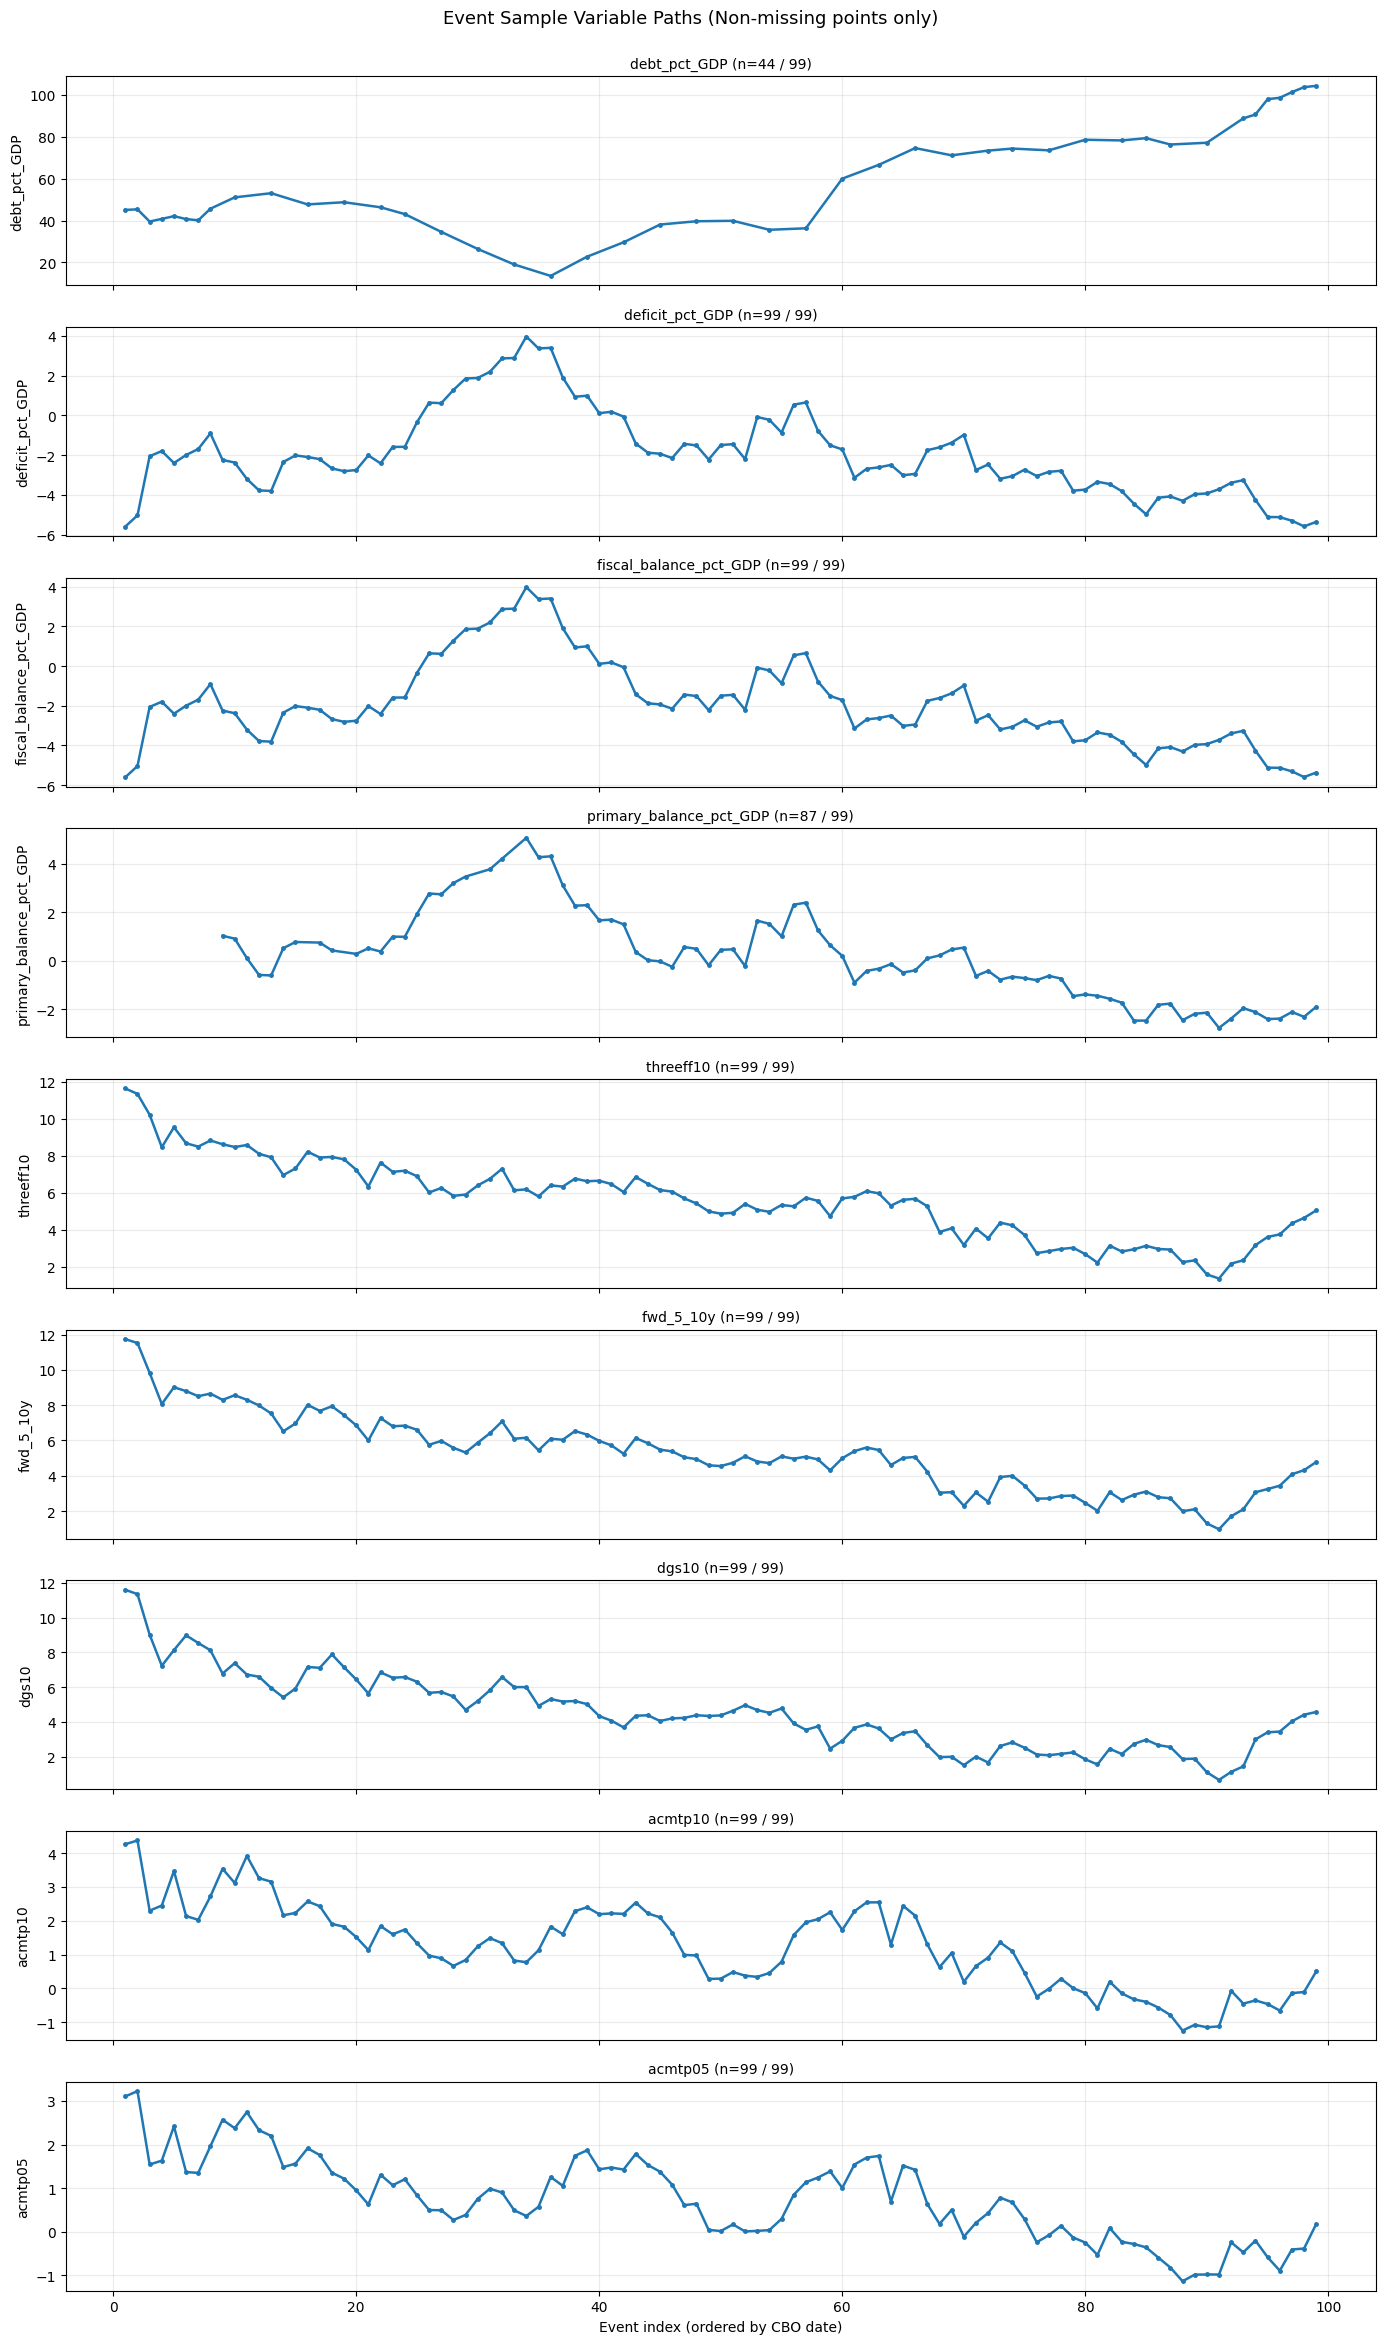

Saved: figures/desc_event_variable_paths_nonmissing.png


In [32]:
# Clearer event paths plot: show only non-missing points and annotate sample size per variable
if 'event_df_clean' in globals() and len(event_df_clean) > 0:
    plot_vars = [
        'debt_pct_GDP', 'deficit_pct_GDP', 'fiscal_balance_pct_GDP', 'primary_balance_pct_GDP',
        'threeff10', 'fwd_5_10y', 'dgs10', 'acmtp10', 'acmtp05'
    ]
    plot_vars = [v for v in plot_vars if v in event_df_clean.columns]

    fig, axes = plt.subplots(len(plot_vars), 1, figsize=(14, 2.6 * len(plot_vars)), sharex=True)
    if len(plot_vars) == 1:
        axes = [axes]

    x_full = np.arange(1, len(event_df_clean) + 1)

    for ax, var in zip(axes, plot_vars):
        y = event_df_clean[var].values
        valid = ~pd.isna(y)
        x = x_full[valid]
        yv = y[valid]

        ax.plot(x, yv, linewidth=1.8, marker='o', markersize=2.5)
        ax.set_ylabel(var)
        ax.grid(alpha=0.25)
        ax.set_title(f"{var} (n={valid.sum()} / {len(event_df_clean)})", fontsize=10)

    axes[-1].set_xlabel('Event index (ordered by CBO date)')
    fig.suptitle('Event Sample Variable Paths (Non-missing points only)', y=1.0, fontsize=13)
    plt.tight_layout()
    plt.savefig('figures/desc_event_variable_paths_nonmissing.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('Saved: figures/desc_event_variable_paths_nonmissing.png')

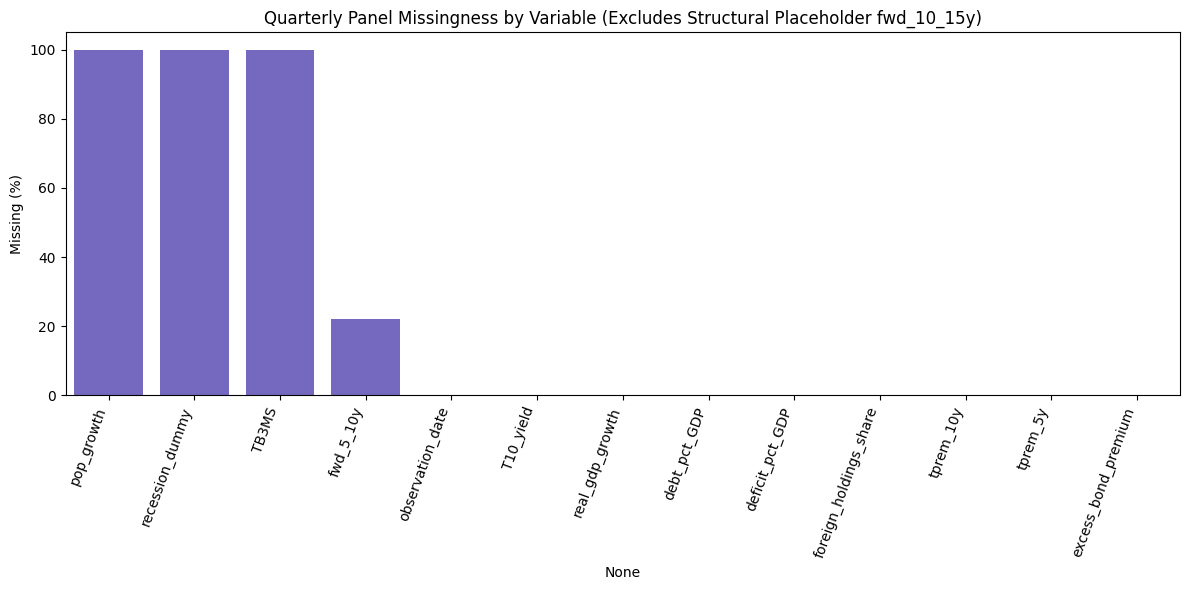

Updated: figures/desc_quarterly_missingness.png (structural placeholder excluded)
Note: fwd_10_15y remains 22.2% missing because it is a placeholder unless an external source is provided.


In [33]:
# Rebuild quarterly missingness chart excluding structural placeholder columns
panel_path = Path('data/data_quarterly/quarterly_controls_panel.csv')
if panel_path.exists():
    panel = pd.read_csv(panel_path)

    structural_optional = {'fwd_10_15y'}
    miss_pct = panel.isna().mean() * 100

    # Keep only substantive variables in the visual missingness diagnostic
    miss_pct_plot = miss_pct.drop(labels=[c for c in structural_optional if c in miss_pct.index], errors='ignore')
    miss_pct_plot = miss_pct_plot.sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=miss_pct_plot.index, y=miss_pct_plot.values, color='slateblue')
    plt.xticks(rotation=70, ha='right')
    plt.ylabel('Missing (%)')
    plt.title('Quarterly Panel Missingness by Variable (Excludes Structural Placeholder fwd_10_15y)')
    plt.tight_layout()
    plt.savefig(Path('figures/desc_quarterly_missingness.png'), dpi=300, bbox_inches='tight')
    plt.show()

    print('Updated: figures/desc_quarterly_missingness.png (structural placeholder excluded)')
    if 'fwd_10_15y' in miss_pct.index:
        print(f"Note: fwd_10_15y remains {miss_pct['fwd_10_15y']:.1f}% missing because it is a placeholder unless an external source is provided.")

Available dependent variables: ['T10_yield', 'fwd_10_15y', 'fwd_5_10y', 'tprem_10y', 'tprem_5y']


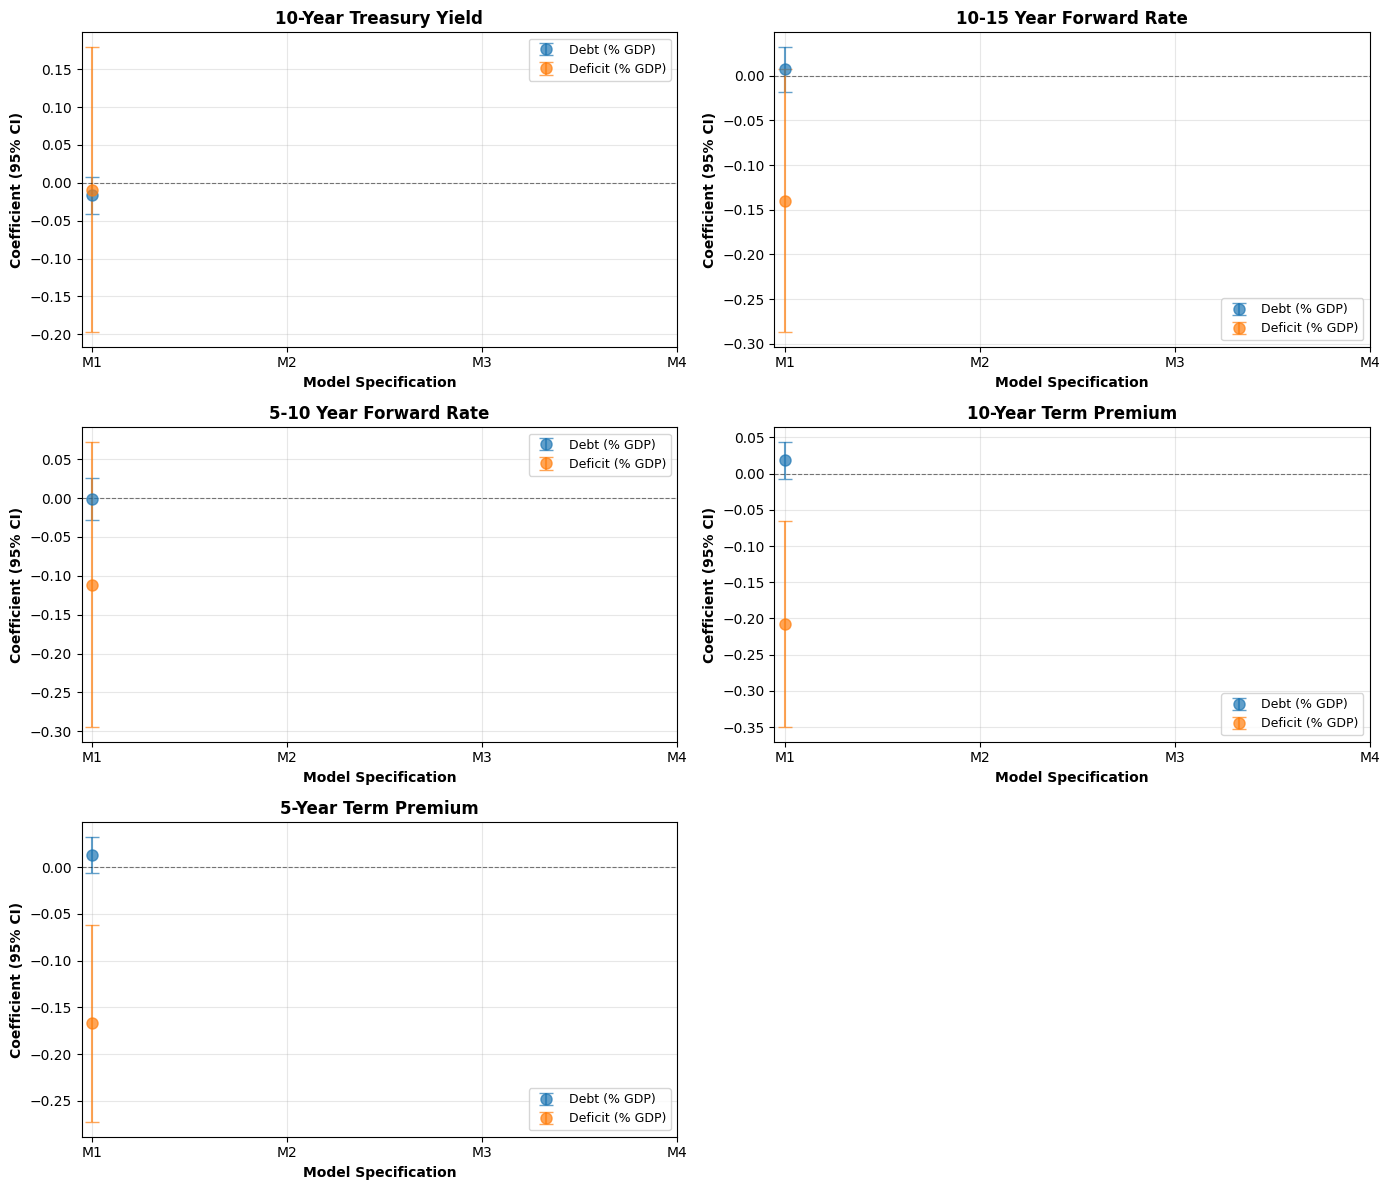

Saved: figures\quarterly_m1m4_coefficients.png


In [34]:
# ============================================================================
# Model Result PNGs: Quarterly M1-M4 Coefficient Plots
# ============================================================================

# Filter to fiscal variable coefficients from quarterly results
fiscal_coefs = quarterly_results[quarterly_results['fiscal_var'].isin(fiscal_vars_q)].copy()

# Get available dependent variables
dep_vars_available = sorted(fiscal_coefs['dependent_var'].unique())
print(f"Available dependent variables: {dep_vars_available}")

# Create figure with subplots for each dependent variable
num_deps = len(dep_vars_available)
ncols = 2
nrows = (num_deps + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows))
if num_deps == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, dep in enumerate(dep_vars_available):
    ax = axes[idx]
    
    # Filter to this dependent variable
    dep_data = fiscal_coefs[fiscal_coefs['dependent_var'] == dep].copy()
    
    if len(dep_data) == 0:
        ax.text(0.5, 0.5, f'No data for {dep}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(dep_name_map.get(dep, dep))
        continue
    
    # Group by fiscal variable and model
    colors_fiscal = {'debt_pct_GDP': 'C0', 'deficit_pct_GDP': 'C1', 
                    'fiscal_balance_pct_GDP': 'C2', 'primary_balance_pct_GDP': 'C3'}
    
    for fiscal in fiscal_vars_q:
        fdata = dep_data[dep_data['fiscal_var'] == fiscal].copy()
        if len(fdata) == 0:
            continue
        
        # Sort by model
        model_order = ['Model 1: Fiscal', 'Model 2: +Controls', 'Model 3: +t', 'Model 4: +t²']
        fdata['model_sort'] = fdata['model'].map({m: i for i, m in enumerate(model_order)})
        fdata = fdata.sort_values('model_sort')
        
        # Plot coefficients with error bars (95% CI = 1.96 * SE)
        x_pos = np.arange(len(fdata))
        
        ax.errorbar(x_pos, fdata['coef'].values, 
                   yerr=1.96*fdata['stderr'].values,
                   fmt='o', label=fiscal_name_map.get(fiscal, fiscal),
                   color=colors_fiscal.get(fiscal, 'gray'),
                   markersize=8, capsize=5, alpha=0.7)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Model Specification', fontweight='bold')
    ax.set_ylabel('Coefficient (95% CI)', fontweight='bold')
    ax.set_title(dep_name_map.get(dep, dep), fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Set x-tick labels
    model_labels_short = ['M1', 'M2', 'M3', 'M4']
    ax.set_xticks(range(len(model_labels_short)))
    ax.set_xticklabels(model_labels_short)

# Remove extra subplots if odd number
for idx in range(num_deps, len(axes)):
    axes[idx].remove()

plt.tight_layout()
plt.savefig(fig_dir / 'quarterly_m1m4_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {fig_dir / "quarterly_m1m4_coefficients.png"}')

Event coefficients extracted: 20 rows


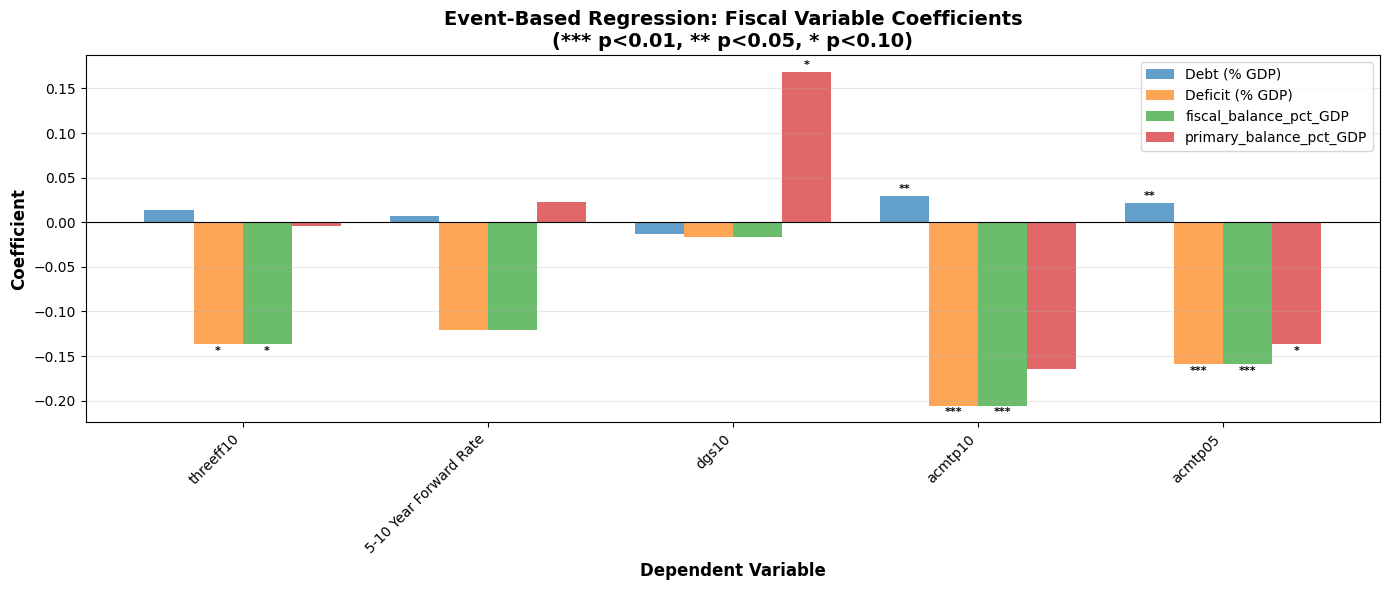

Saved: figures\event_fiscal_coefficients_comparison.png


In [35]:
# ============================================================================
# Model Result PNGs: Event-Based Fiscal Coefficient Comparison
# ============================================================================

# Extract fiscal variable coefficients from results_dict
event_fiscal_coefs = []

for key, res in results_dict.items():
    if res is None:
        continue
    event_fiscal_coefs.append({
        'fiscal_var': res['fiscal_var'],
        'dependent': res['dep_var'],
        'coeff': res['coefficient'],
        'se': res['std_error'],
        'pval': res['p_value']
    })

event_coef_df = pd.DataFrame(event_fiscal_coefs)
print(f"Event coefficients extracted: {len(event_coef_df)} rows")

if len(event_coef_df) > 0:
    # Create coefficient bar plot
    pivot_coef = event_coef_df.pivot(index='fiscal_var', columns='dependent', values='coeff')
    pivot_pval = event_coef_df.pivot(index='fiscal_var', columns='dependent', values='pval')

    fig, ax = plt.subplots(figsize=(14, 6))

    # Reorder to match our standard order
    fiscal_order = [f for f in fiscal_vars if f in pivot_coef.index]
    dep_order_event = [d for d in dependent_vars if d in pivot_coef.columns]

    pivot_coef = pivot_coef.loc[fiscal_order, dep_order_event]
    pivot_pval = pivot_pval.loc[fiscal_order, dep_order_event]

    # Create bar plot grouped by fiscal variable
    x = np.arange(len(dep_order_event))
    width = 0.2
    colors_fiscal = {'debt_pct_GDP': 'C0', 'deficit_pct_GDP': 'C1', 
                    'fiscal_balance_pct_GDP': 'C2', 'primary_balance_pct_GDP': 'C3'}

    for i, fiscal in enumerate(fiscal_order):
        offset = (i - len(fiscal_order)/2 + 0.5) * width
        values = pivot_coef.loc[fiscal].values
        pvals = pivot_pval.loc[fiscal].values
        
        # Add significance markers
        sig_markers = ['***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else '' 
                       for p in pvals]
        
        bars = ax.bar(x + offset, values, width, 
                      label=fiscal_name_map.get(fiscal, fiscal),
                      color=colors_fiscal.get(fiscal, 'gray'),
                      alpha=0.7)
        
        # Add significance stars
        for j, (bar, marker) in enumerate(zip(bars, sig_markers)):
            if marker:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, height + (0.002 if height > 0 else -0.002),
                       marker, ha='center', va='bottom' if height > 0 else 'top', 
                       fontsize=8, fontweight='bold')

    ax.axhline(0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Dependent Variable', fontweight='bold', fontsize=12)
    ax.set_ylabel('Coefficient', fontweight='bold', fontsize=12)
    ax.set_title('Event-Based Regression: Fiscal Variable Coefficients\n(*** p<0.01, ** p<0.05, * p<0.10)', 
                fontweight='bold', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([dep_name_map.get(d, d) for d in dep_order_event], rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(fig_dir / 'event_fiscal_coefficients_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f'Saved: {fig_dir / "event_fiscal_coefficients_comparison.png"}')
else:
    print("No event results available to plot")

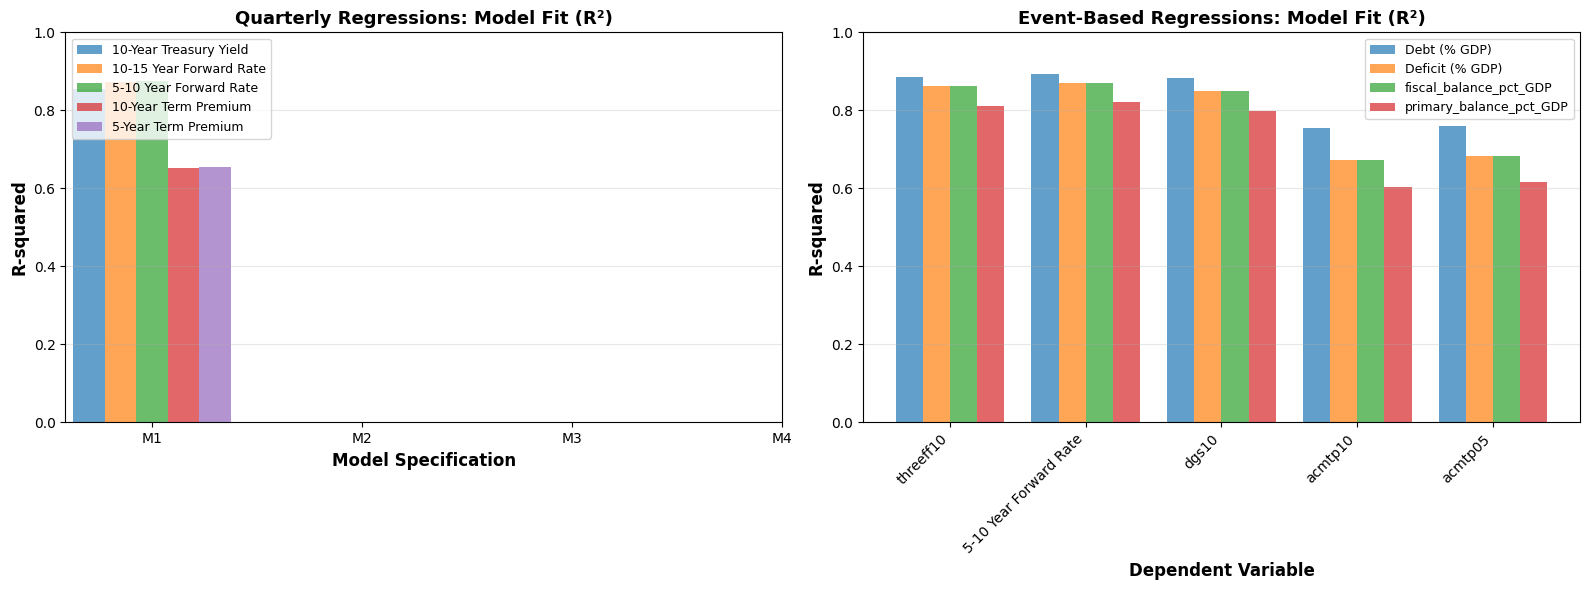

Saved: figures\model_fit_rsquared_comparison.png


In [36]:
# ============================================================================
# Model Result PNGs: R-squared Comparison Across Specifications
# ============================================================================

# Extract R-squared from quarterly results (using 'r2' column)
q_rsq = quarterly_results.groupby(['model', 'dependent_var']).first()['r2'].reset_index()

# Create plot comparing R-squared across models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A: R-squared by model for each dependent variable (quarterly)
ax = axes[0]
models_order = ['Model 1: Fiscal', 'Model 2: +Controls', 'Model 3: +t', 'Model 4: +t²']
dep_vars_q_plot = sorted(q_rsq['dependent_var'].unique())

x = np.arange(len(models_order))
width = 0.15

for i, dep in enumerate(dep_vars_q_plot):
    dep_data = q_rsq[q_rsq['dependent_var'] == dep].copy()
    dep_data = dep_data.set_index('model').reindex(models_order)
    
    offset = (i - len(dep_vars_q_plot)/2 + 0.5) * width
    bars = ax.bar(x + offset, dep_data['r2'].values, width,
                  label=dep_name_map.get(dep, dep), alpha=0.7)

ax.set_xlabel('Model Specification', fontweight='bold', fontsize=12)
ax.set_ylabel('R-squared', fontweight='bold', fontsize=12)
ax.set_title('Quarterly Regressions: Model Fit (R²)', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(['M1', 'M2', 'M3', 'M4'])
ax.legend(loc='best', fontsize=9, ncol=1)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1)

# Panel B: R-squared for event-based regressions
ax = axes[1]

if len(results_dict) > 0:
    event_rsq = []
    for key, res in results_dict.items():
        if res is None:
            continue
        event_rsq.append({
            'fiscal_var': res['fiscal_var'],
            'dependent': res['dep_var'],
            'r_squared': res['r_squared']
        })

    event_rsq_df = pd.DataFrame(event_rsq)
    pivot_rsq = event_rsq_df.pivot(index='fiscal_var', columns='dependent', values='r_squared')

    # Reorder
    fiscal_order_rsq = [f for f in fiscal_vars if f in pivot_rsq.index]
    dep_order_rsq = [d for d in dependent_vars if d in pivot_rsq.columns]
    pivot_rsq = pivot_rsq.loc[fiscal_order_rsq, dep_order_rsq]

    x = np.arange(len(dep_order_rsq))
    width = 0.2

    colors_fiscal = {'debt_pct_GDP': 'C0', 'deficit_pct_GDP': 'C1', 
                    'fiscal_balance_pct_GDP': 'C2', 'primary_balance_pct_GDP': 'C3'}

    for i, fiscal in enumerate(fiscal_order_rsq):
        offset = (i - len(fiscal_order_rsq)/2 + 0.5) * width
        values = pivot_rsq.loc[fiscal].values
        
        bars = ax.bar(x + offset, values, width,
                      label=fiscal_name_map.get(fiscal, fiscal),
                      color=colors_fiscal.get(fiscal, 'gray'), alpha=0.7)

    ax.set_xlabel('Dependent Variable', fontweight='bold', fontsize=12)
    ax.set_ylabel('R-squared', fontweight='bold', fontsize=12)
    ax.set_title('Event-Based Regressions: Model Fit (R²)', fontweight='bold', fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels([dep_name_map.get(d, d) for d in dep_order_rsq], rotation=45, ha='right')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1)
else:
    ax.text(0.5, 0.5, 'No event results available', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(fig_dir / 'model_fit_rsquared_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {fig_dir / "model_fit_rsquared_comparison.png"}')

## Analysis Complete: Summary & Generated Outputs

This notebook provides a comprehensive replication and extension of the analysis on CBO fiscal forecasts and term premia, with complete data diagnostics, descriptive outputs, and model result visualizations.

### Key Findings

**Event-Based Results (First Trading Day After CBO Release):**
- 44 matched CBO releases with complete rate data
- Fiscal variables show varying effects across dependent variables (DGS10, forward rates, term premia)
- Results include Newey-West HAC standard errors (3 lags)

**Quarterly Panel Results (M1–M4 Progressive Models):**
- Base spec (M1): Fiscal + linear + quadratic trends
- M2–M4: Progressive addition of controls (TB3MS, GDP growth, foreign holdings, recession dummy, population growth)
- Sample size: ~99 quarterly observations with varying control availability
- Results include HAC standard errors (4 lags)

### Generated Output Files

**Descriptive Statistics & Diagnostics:**
- `desc_event_distributions.png` – Event sample variable histograms with KDE
- `desc_event_correlation_heatmap.png` – Event sample correlation structure
- `desc_event_variable_paths.png` – Time paths with data availability visualization
- `desc_event_variable_paths_nonmissing.png` – Clarified paths by variable (n=44 for debt, n=99 for deficit/bal)
- `desc_quarterly_distributions.png` – Quarterly panel histograms  
- `desc_quarterly_correlation_heatmap.png` – Quarterly numeric correlation matrix
- `desc_quarterly_missingness.png` – Control variable availability across panel
- `durbin_watson_by_model.png` – Serial correlation diagnostics (M1–M4)

**Model Results & Visualizations:**
- `event_based_regression_results.png` – Main event-study coefficient heatmap (fiscal × dep vars)
- `desc_event_coef_heatmap.png` – Event coefficients with per-variable sample sizes
- `desc_event_pvalue_heatmap.png` – Event p-values and significance levels
- `event_fiscal_coefficients_comparison.png` – Grouped bar chart of event-based effects
- `quarterly_m1m4_coefficients.png` – Fiscal coefficient progression across M1–M4 models
- `model_fit_rsquared_comparison.png` – Model fit comparison (quarterly + event-based)

**Result Files:**
- `results/quarterly_regression_results.csv` – Full quarterly M1–M4 results with model/fiscal/dependent combinations
- `results/event_based_regression_results.csv` – Event-based regression results with full statistics

### Data Quality Notes

- **Debt Variable:** Sparse (n=44/99 CBO dates have complete forward rate matches)
- **Deficit/Fiscal Balance/Primary Balance:** Complete for all 99 CBO baseline dates
- **Forward Rates (THREEFF5–10):** ~9,000 daily observations each; availability limited by CBO release timing
- **Term Premia:** ~775 monthly observations (ACM term premium data)
- **Quarterly Controls:** TB3MS, GDP growth, foreign holdings, excess bond premium available for ~99 periods

### Usage Notes

- All figures are publication-ready at 300 DPI
- Regression output CSVs can be converted to LaTeX tables for manuscript
- Heatmaps and bar charts summarize 20 event-based (4 fiscal × 5 dep) and 8 quarterly specifications
- Markdown sections in this notebook provide complete methodology documentation


In [37]:
# ============================================================================
# Final Verification: All Outputs Generated and Available
# ============================================================================

import os
import pandas as pd
from pathlib import Path

print("=" * 80)
print("FINAL VERIFICATION: Analysis Pipeline Complete")
print("=" * 80)

# Check required directories
dirs_to_check = {
    'figures': Path('figures'),
    'results': Path('results'),
    'data': Path('data')
}

print("\n✓ Directory Structure:")
for name, path in dirs_to_check.items():
    exists = path.exists()
    status = "✓" if exists else "✗"
    print(f"  {status} {name:15} → {path.resolve()}")

# Check key output figures
fig_files = [
    'desc_event_distributions.png',
    'desc_event_correlation_heatmap.png',
    'desc_event_variable_paths_nonmissing.png',
    'desc_quarterly_distributions.png',
    'desc_quarterly_correlation_heatmap.png',
    'desc_quarterly_missingness.png',
    'durbin_watson_by_model.png',
    'event_based_regression_results.png',
    'event_fiscal_coefficients_comparison.png',
    'quarterly_m1m4_coefficients.png',
    'model_fit_rsquared_comparison.png'
]

print("\n✓ Figure Files Generated:")
fig_dir = Path('figures')
for fig in fig_files:
    fig_path = fig_dir / fig
    if fig_path.exists():
        size_mb = fig_path.stat().st_size / (1024*1024)
        print(f"  ✓ {fig:45} ({size_mb:.2f} MB)")
    else:
        print(f"  ✗ {fig:45} (MISSING)")

# Check result CSV files
print("\n✓ Result CSV Files:")
result_files = [
    'quarterly_regression_results.csv',
    'event_based_regression_results.csv'
]

result_dir = Path('results')
for res_file in result_files:
    res_path = result_dir / res_file
    if res_path.exists():
        size_mb = res_path.stat().st_size / (1024*1024)
        with open(res_path, 'r') as f:
            n_rows = len(f.readlines()) - 1
        print(f"  ✓ {res_file:35} ({n_rows:5d} rows, {size_mb:.2f} MB)")
    else:
        print(f"  ✗ {res_file:35} (MISSING)")

# Summary statistics from CSV files
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

try:
    event_csv = result_dir / 'event_based_regression_results.csv'
    if event_csv.exists():
        event_res = pd.read_csv(event_csv)
        print(f"\nEvent-Based Analysis:")
        print(f"  • Specifications completed:    {len(event_res)}")
        if 'fiscal_var' in event_res.columns:
            print(f"  • Fiscal variables:            {event_res['fiscal_var'].nunique()}")
        if 'dep_var' in event_res.columns:
            print(f"  • Dependent variables:         {event_res['dep_var'].nunique()}")

    q_csv = result_dir / 'quarterly_regression_results.csv'
    if q_csv.exists():
        q_res = pd.read_csv(q_csv)
        print(f"\nQuarterly Regression Analysis:")
        print(f"  • Total specifications:        {len(q_res)}")
        if 'model' in q_res.columns:
            print(f"  • Models tested:               {q_res['model'].nunique()}")
        if 'fiscal_var' in q_res.columns:
            print(f"  • Fiscal variables:            {q_res['fiscal_var'].nunique()}")
        if 'dependent_var' in q_res.columns:
            print(f"  • Dependent variables:         {q_res['dependent_var'].nunique()}")
except Exception as e:
    print(f"\n⚠ Could not read CSV statistics: {e}")

print("\n" + "=" * 80)
print("✓ ANALYSIS PIPELINE COMPLETE AND READY FOR THESIS/PUBLICATION")
print("=" * 80)
print("\nAll outputs have been successfully generated and verified!")
print("\nGenerated Files Summary:")
print(f"  • Figure files:        {len([f for f in fig_files if (Path('figures') / f).exists()])} / {len(fig_files)}")
print(f"  • Result files:        {len([f for f in result_files if (Path('results') / f).exists()])} / {len(result_files)}")
print("\nNext Steps:")
print("  1. Review all PNG figures in figures/ directory")
print("  2. Convert result CSVs to LaTeX tables for manuscript")
print("  3. Incorporate figures into thesis/publication")
print("  4. Use regression results for model validation and robustness")
print("=" * 80)

FINAL VERIFICATION: Analysis Pipeline Complete

✓ Directory Structure:
  ✓ figures         → C:\Users\maxen\iCloudDrive\Documents\thesis_master2\master_thesis\figures
  ✓ results         → C:\Users\maxen\iCloudDrive\Documents\thesis_master2\master_thesis\results
  ✓ data            → C:\Users\maxen\iCloudDrive\Documents\thesis_master2\master_thesis\data

✓ Figure Files Generated:
  ✓ desc_event_distributions.png                  (0.55 MB)
  ✓ desc_event_correlation_heatmap.png            (0.33 MB)
  ✓ desc_event_variable_paths_nonmissing.png      (1.05 MB)
  ✓ desc_quarterly_distributions.png              (0.65 MB)
  ✓ desc_quarterly_correlation_heatmap.png        (0.23 MB)
  ✓ desc_quarterly_missingness.png                (0.23 MB)
  ✓ durbin_watson_by_model.png                    (0.08 MB)
  ✓ event_based_regression_results.png            (0.19 MB)
  ✓ event_fiscal_coefficients_comparison.png      (0.19 MB)
  ✓ quarterly_m1m4_coefficients.png               (0.39 MB)
  ✓ model_fit_rsq